In [1]:
!git clone https://github.com/VladWero08/time-series-ad-gan.git

Cloning into 'time-series-ad-gan'...
remote: Enumerating objects: 513, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 513 (delta 48), reused 61 (delta 26), pack-reused 427 (from 1)
Receiving objects: 100% (513/513), 16.48 MiB | 26.78 MiB/s, done.
Resolving deltas: 100% (306/306), done.


In [2]:
!pip install -r time-series-ad-gan/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 698.9/698.9 kB 17.7 MB/s eta 0:00:0000:01
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [3]:
import sys 
import os

module_path = os.path.abspath("./time-series-ad-gan")
if module_path not in sys.path:
    sys.path.append(module_path)

In [ ]:
import ast
import pandas as pd
import numpy as np
import json
import kagglehub
import typing as t
import torch
import matplotlib.pyplot as plt
from urllib.request import urlopen

from src.models.lstm_ae import run_pipeline
from src.utils.data import intervals_to_points

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Working on {device}!")

Working on cuda!


In [6]:
def plot_signal(X: np.ndarray, y: np.ndarray) -> None:
    plt.figure(figsize=(15, 4))
    for idx in np.where(y == 1)[0]:
        plt.axvline(idx, color='red', alpha=0.4, linewidth=0.8, zorder=0)
    plt.plot(X, zorder=1)
    plt.show()

## **NAB**

In [7]:
NAB_REPO = "https://raw.githubusercontent.com/numenta/NAB/refs/heads/master/data/"

ART_FOLDER = "artificialWithAnomaly/"
ART_FILE_NAMES = [
    "art_daily_flatmiddle",
    "art_daily_jumpsdown",
    "art_daily_jumpsup",
    "art_daily_nojump",
    "art_increase_spike_density",
    "art_load_balancer_spikes"
]

AD_EX_FOLDER = "realAdExchange/"
AD_EX_FILE_NAMES = [
    "exchange-2_cpc_results",
    "exchange-2_cpm_results",
    "exchange-3_cpc_results",
    "exchange-3_cpm_results",
    "exchange-4_cpc_results",
    "exchange-4_cpm_results",
]

AWS_FOLDER = "realAWSCloudwatch/"
AWS_FILE_NAMES = [
    "ec2_cpu_utilization_24ae8d",
    "ec2_cpu_utilization_53ea38",
    "ec2_cpu_utilization_5f5533",
    "ec2_cpu_utilization_77c1ca",
    "ec2_cpu_utilization_825cc2",
    "ec2_cpu_utilization_ac20cd",
    "ec2_cpu_utilization_c6585a",
    "ec2_cpu_utilization_fe7f93",
    "ec2_disk_write_bytes_1ef3de",
    "ec2_disk_write_bytes_c0d644",
    "ec2_network_in_257a54",
    "ec2_network_in_5abac7",
    "elb_request_count_8c0756",
    "grok_asg_anomaly",
    "iio_us-east-1_i-a2eb1cd9_NetworkIn",
    "rds_cpu_utilization_cc0c53",
    "rds_cpu_utilization_e47b3b"
]

TRAFFIC_FOLDER = "realTraffic/"
TRAFFIC_FILE_NAMES = [
    "TravelTime_387",
    "TravelTime_451",
    "occupancy_6005",
    "occupancy_t4013",
    "speed_6005",
    "speed_7578",
    "speed_t4013"
]

TWEETS_FOLDER = "realTweets/"
TWEETS_FILE_NAMES = [
    "Twitter_volume_AAPL",
    "Twitter_volume_AMZN",
    "Twitter_volume_CRM",
    "Twitter_volume_CVS",
    "Twitter_volume_FB",
    "Twitter_volume_GOOG",
    "Twitter_volume_IBM",
    "Twitter_volume_KO",
    "Twitter_volume_PFE",
    "Twitter_volume_UPS"
]

NAB_LABELS = "https://raw.githubusercontent.com/numenta/NAB/refs/heads/master/labels/combined_windows.json"

In [8]:
NAB_HYPERPARAMS = {
    "train_ratio": 0.6,
    "val_ratio": 0.1,
    "lr": 1e-4,
    "epochs": 200,
    "patience": 15,
    "device": device,
    "anomaly_type": "contextual",
    "verbose": True,
}

In [9]:
with urlopen(NAB_LABELS) as labels_url:
    nab_labels = json.loads(labels_url.read().decode())

In [10]:
def nab_download_subdataset(folder: str, file_names: list[str], nab_labels: dict) -> t.List[pd.DataFrame]:
    nab_signals = []
    nab_points = 0
    nab_anomalies = 0

    for i, fn in enumerate(file_names):
        # name of the .csv in the repository
        nab_ts_fn = f"{fn}.csv"
        # url to the raw .csv file in the repository
        nab_ts_url = f"{NAB_REPO}{folder}{nab_ts_fn}"

        nab_ts_df = pd.read_csv(nab_ts_url)
        nab_ts_df["is_anomaly"] = 0

        # iterate through the contextualized anomalies for each .csv file,
        # and if the timestamp is inside one of the intervals, toggle the is_anomaly attribute
        for start, end in nab_labels[f"{folder}{nab_ts_fn}"]:
            start = pd.Timestamp(start)
            end = pd.Timestamp(end)
            interval = pd.Interval(start, end, closed="both")

            nab_ts_df.loc[
                nab_ts_df["timestamp"].map(lambda ts: pd.Timestamp(ts) in interval),
                "is_anomaly"
            ] = 1

        nab_signals.append(nab_ts_df)
        nab_points += len(nab_ts_df)
        nab_anomalies += (nab_ts_df["is_anomaly"] == 1).sum()

        if (i + 1) % 5 == 0:
            print(f"Downloaded {i + 1} .csv files.")

    print()
    print(f"Finished downloading {folder}!")
    print("---------------------")
    print(f"Total Signals: {len(file_names)}")
    print(F"Total Points: {nab_points}")
    print(f"Total Anomaly Points: {nab_anomalies}")
    print(f"Anomaly Rate: {(nab_anomalies / nab_points) * 100:.2f}%")

    return nab_signals

### **Artificial with Anomaly**

In [11]:
ART_HYPERPARAMS = NAB_HYPERPARAMS.copy()
ART_HYPERPARAMS["train_ratio"] = 0.5

In [12]:
art_signals = nab_download_subdataset(folder=ART_FOLDER, file_names=ART_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.

Finished downloading artificialWithAnomaly/!
---------------------
Total Signals: 6
Total Points: 24192
Total Anomaly Points: 2418
Anomaly Rate: 10.00%


--------------
Art Signal 1
--------------


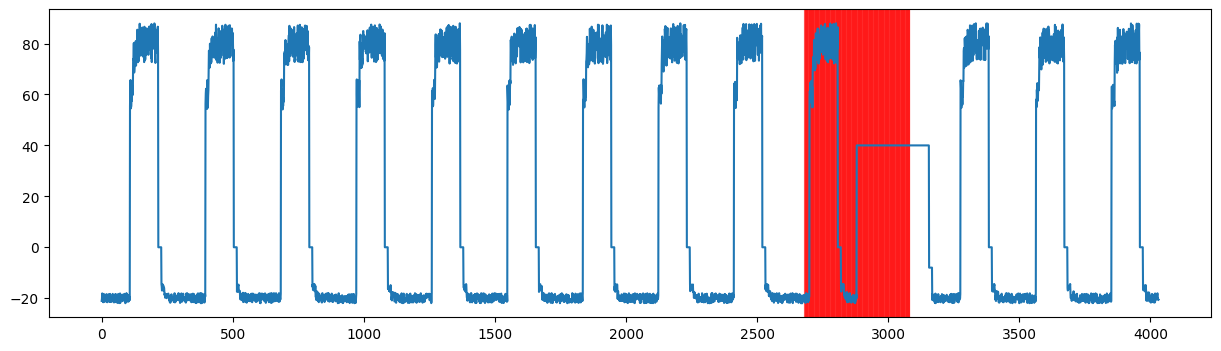

Epoch   5 | Train Loss: 0.565398 | Val Loss: 0.454743
Epoch  10 | Train Loss: 0.324493 | Val Loss: 0.294824
Epoch  15 | Train Loss: 0.215742 | Val Loss: 0.203239
Epoch  20 | Train Loss: 0.181914 | Val Loss: 0.166430
Epoch  25 | Train Loss: 0.074803 | Val Loss: 0.076491
Epoch  30 | Train Loss: 0.075127 | Val Loss: 0.066970
Epoch  35 | Train Loss: 0.054920 | Val Loss: 0.056475
Epoch  40 | Train Loss: 0.050583 | Val Loss: 0.050672
Epoch  45 | Train Loss: 0.042862 | Val Loss: 0.041260
Epoch  50 | Train Loss: 0.042131 | Val Loss: 0.043820
Epoch  55 | Train Loss: 0.036833 | Val Loss: 0.036144
Epoch  60 | Train Loss: 0.033600 | Val Loss: 0.031316
Epoch  65 | Train Loss: 0.031867 | Val Loss: 0.043437
Epoch  70 | Train Loss: 0.027803 | Val Loss: 0.027477
Epoch  75 | Train Loss: 0.027922 | Val Loss: 0.027474
Epoch  80 | Train Loss: 0.025922 | Val Loss: 0.024432
Epoch  85 | Train Loss: 0.024237 | Val Loss: 0.023465
Epoch  90 | Train Loss: 0.024321 | Val Loss: 0.029773
Epoch  95 | Train Loss: 0.02

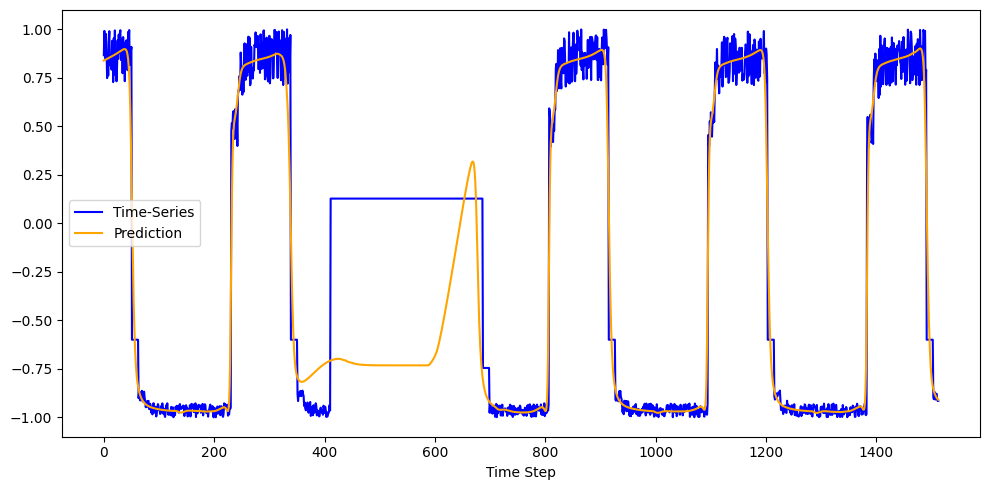

--------------
Art Signal 2
--------------


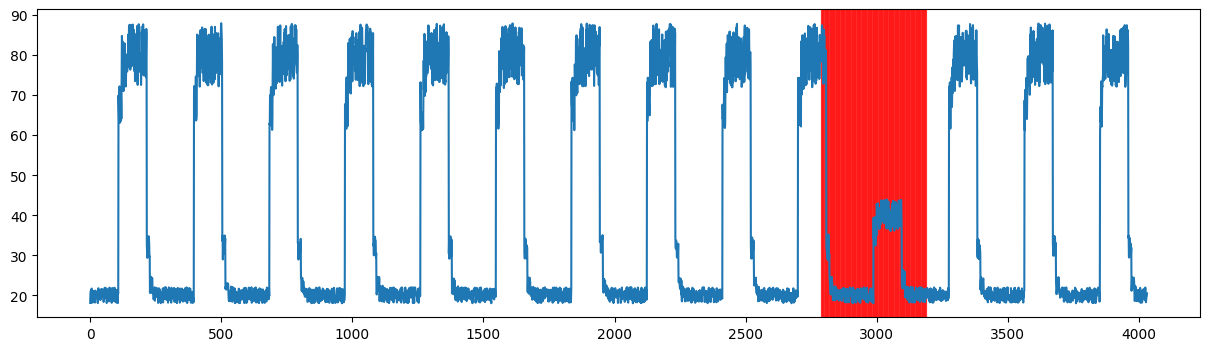

Epoch   5 | Train Loss: 0.527622 | Val Loss: 0.449415
Epoch  10 | Train Loss: 0.291474 | Val Loss: 0.248324
Epoch  15 | Train Loss: 0.213007 | Val Loss: 0.194996
Epoch  20 | Train Loss: 0.185677 | Val Loss: 0.177142
Epoch  25 | Train Loss: 0.178915 | Val Loss: 0.169186
Epoch  30 | Train Loss: 0.155615 | Val Loss: 0.145594
Epoch  35 | Train Loss: 0.103859 | Val Loss: 0.102995
Epoch  40 | Train Loss: 0.090382 | Val Loss: 0.093333
Epoch  45 | Train Loss: 0.072143 | Val Loss: 0.068517
Epoch  50 | Train Loss: 0.063256 | Val Loss: 0.063013
Epoch  55 | Train Loss: 0.061406 | Val Loss: 0.058847
Epoch  60 | Train Loss: 0.061468 | Val Loss: 0.057716
Epoch  65 | Train Loss: 0.053939 | Val Loss: 0.054266
Epoch  70 | Train Loss: 0.048385 | Val Loss: 0.050303
Epoch  75 | Train Loss: 0.045392 | Val Loss: 0.046692
Epoch  80 | Train Loss: 0.042850 | Val Loss: 0.044895
Epoch  85 | Train Loss: 0.041967 | Val Loss: 0.045087
Epoch  90 | Train Loss: 0.041615 | Val Loss: 0.040386
Epoch  95 | Train Loss: 0.03

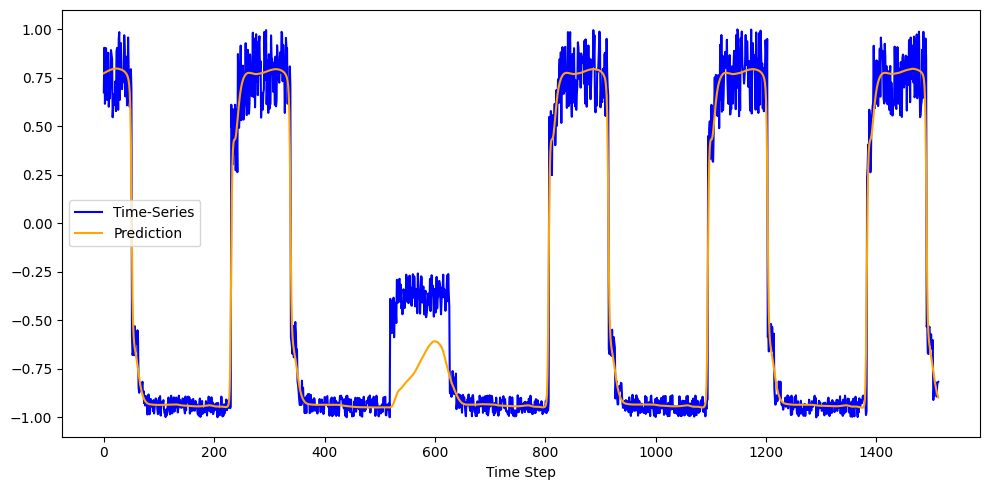

--------------
Art Signal 3
--------------


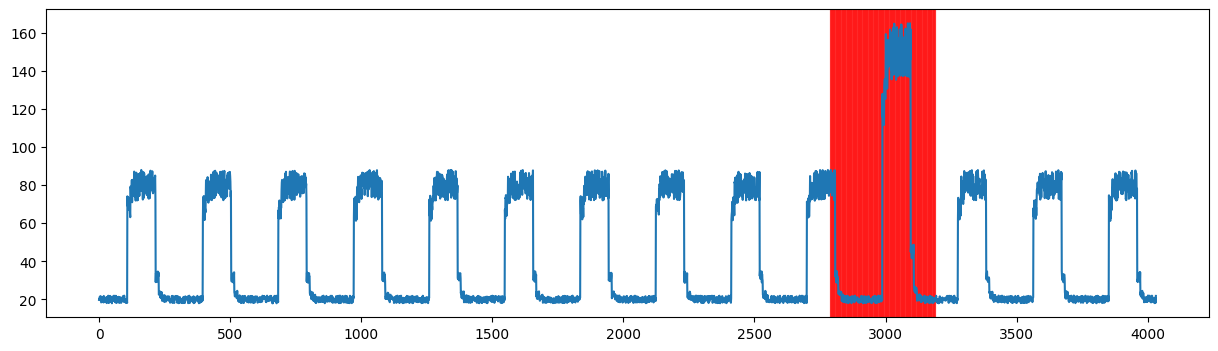

Epoch   5 | Train Loss: 0.559220 | Val Loss: 0.520715
Epoch  10 | Train Loss: 0.303375 | Val Loss: 0.268785
Epoch  15 | Train Loss: 0.080448 | Val Loss: 0.112383
Epoch  20 | Train Loss: 0.055400 | Val Loss: 0.051389
Epoch  25 | Train Loss: 0.054113 | Val Loss: 0.079593
Epoch  30 | Train Loss: 0.043427 | Val Loss: 0.035813
Epoch  35 | Train Loss: 0.034683 | Val Loss: 0.043673
Epoch  40 | Train Loss: 0.032671 | Val Loss: 0.031874
Epoch  45 | Train Loss: 0.031732 | Val Loss: 0.036404
Epoch  50 | Train Loss: 0.034899 | Val Loss: 0.030420
Epoch  55 | Train Loss: 0.031342 | Val Loss: 0.036363
Epoch  60 | Train Loss: 0.026121 | Val Loss: 0.036555
Epoch  65 | Train Loss: 0.035895 | Val Loss: 0.045456
Epoch  70 | Train Loss: 0.025885 | Val Loss: 0.024757
Epoch  75 | Train Loss: 0.025029 | Val Loss: 0.022475
Epoch  80 | Train Loss: 0.028055 | Val Loss: 0.023999
Epoch  85 | Train Loss: 0.024643 | Val Loss: 0.027935
Epoch  90 | Train Loss: 0.021040 | Val Loss: 0.025793
Epoch  95 | Train Loss: 0.02

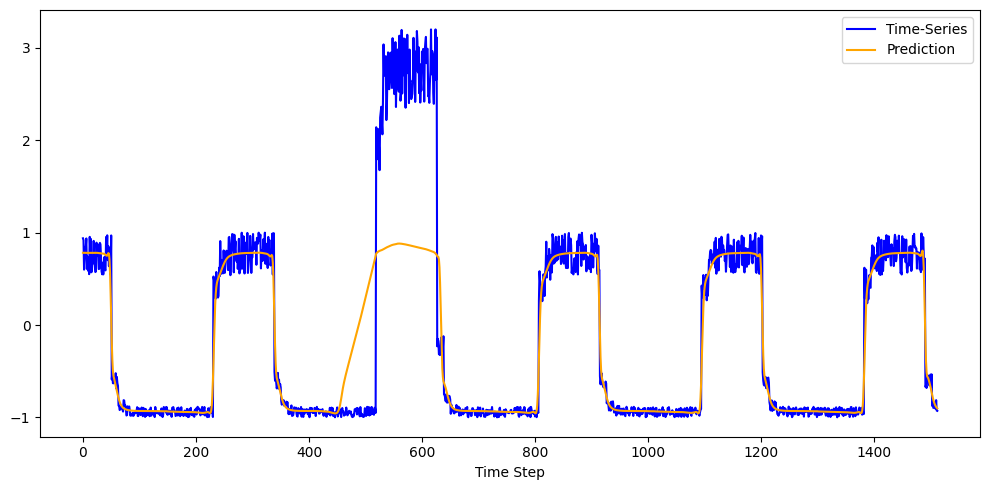

--------------
Art Signal 4
--------------


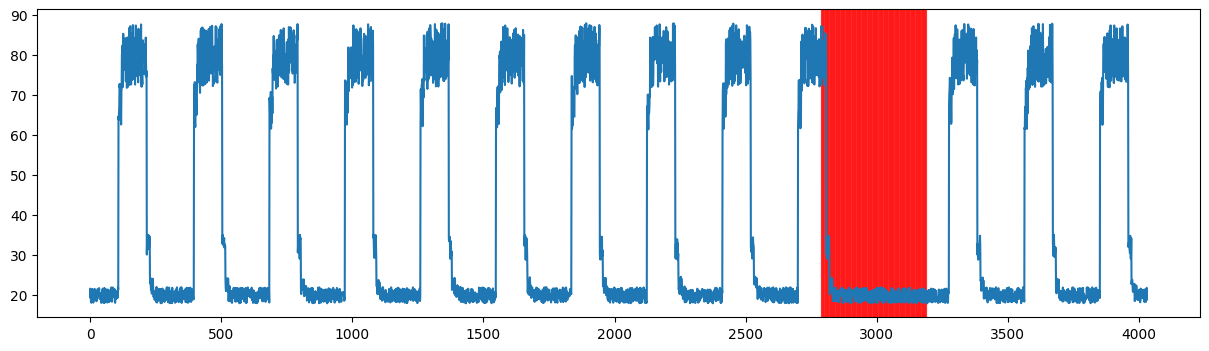

Epoch   5 | Train Loss: 0.541832 | Val Loss: 0.496863
Epoch  10 | Train Loss: 0.314592 | Val Loss: 0.295874
Epoch  15 | Train Loss: 0.246760 | Val Loss: 0.228281
Epoch  20 | Train Loss: 0.195521 | Val Loss: 0.187807
Epoch  25 | Train Loss: 0.177717 | Val Loss: 0.173917
Epoch  30 | Train Loss: 0.166244 | Val Loss: 0.158378
Epoch  35 | Train Loss: 0.155257 | Val Loss: 0.152914
Epoch  40 | Train Loss: 0.152161 | Val Loss: 0.148063
Epoch  45 | Train Loss: 0.124309 | Val Loss: 0.124306
Epoch  50 | Train Loss: 0.102797 | Val Loss: 0.093735
Epoch  55 | Train Loss: 0.084432 | Val Loss: 0.086566
Epoch  60 | Train Loss: 0.075707 | Val Loss: 0.082525
Epoch  65 | Train Loss: 0.064168 | Val Loss: 0.064982
Epoch  70 | Train Loss: 0.062401 | Val Loss: 0.087885
Epoch  75 | Train Loss: 0.059397 | Val Loss: 0.059116
Epoch  80 | Train Loss: 0.051318 | Val Loss: 0.055905
Epoch  85 | Train Loss: 0.048387 | Val Loss: 0.052167
Epoch  90 | Train Loss: 0.049685 | Val Loss: 0.049786
Epoch  95 | Train Loss: 0.04

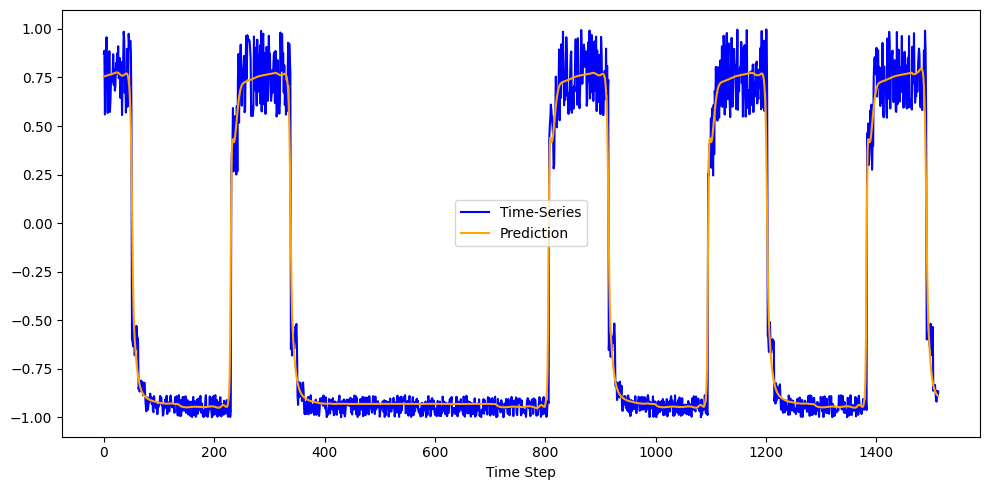

--------------
Art Signal 5
--------------


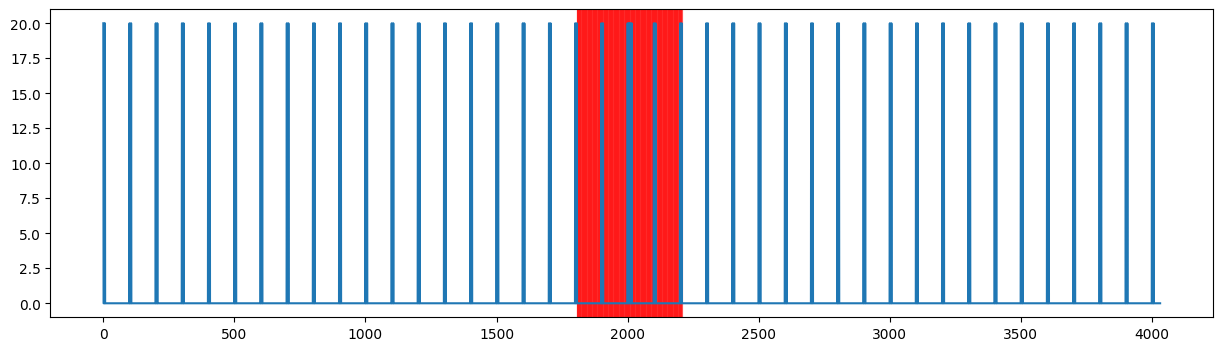

Epoch   5 | Train Loss: 0.090365 | Val Loss: 0.088703
Epoch  10 | Train Loss: 0.079007 | Val Loss: 0.078582
Epoch  15 | Train Loss: 0.078899 | Val Loss: 0.078526
Epoch  20 | Train Loss: 0.078846 | Val Loss: 0.078480
Epoch  25 | Train Loss: 0.078805 | Val Loss: 0.078443
Epoch  30 | Train Loss: 0.078772 | Val Loss: 0.078412
Early stopping at epoch 34

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


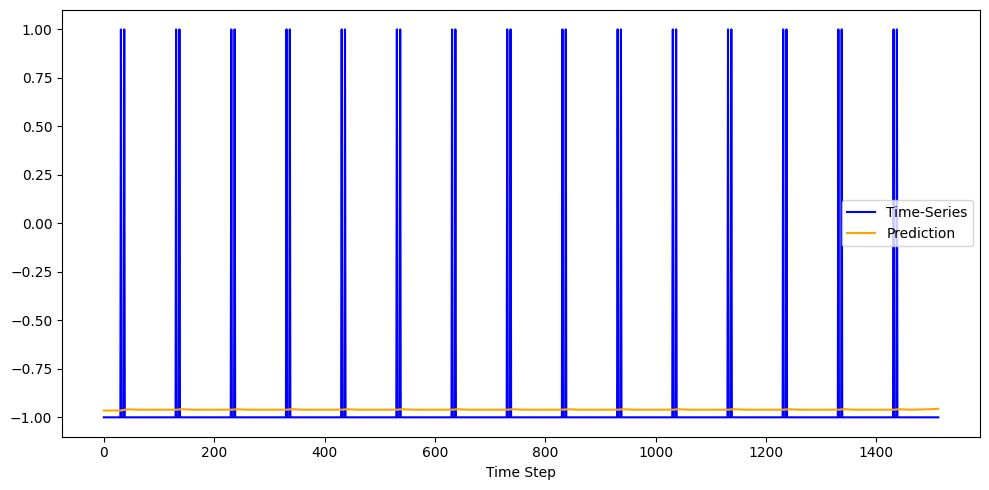

--------------
Art Signal 6
--------------


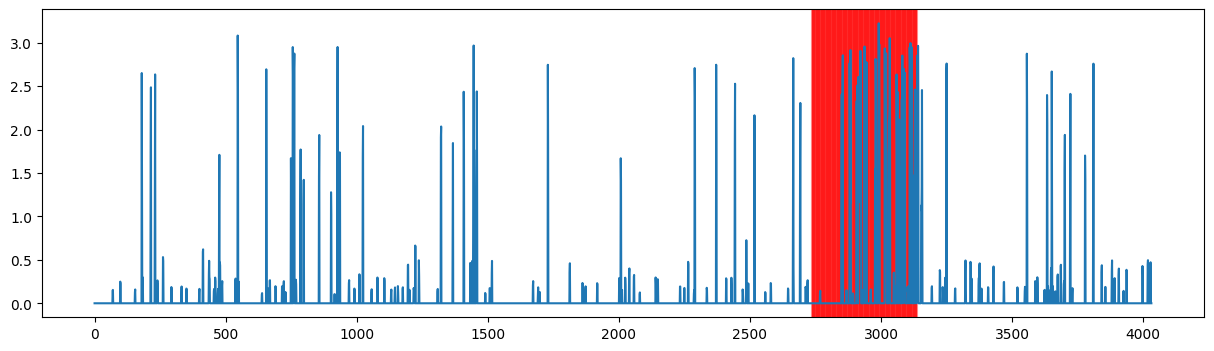

Epoch   5 | Train Loss: 0.051709 | Val Loss: 0.035349
Epoch  10 | Train Loss: 0.041688 | Val Loss: 0.026221
Epoch  15 | Train Loss: 0.041643 | Val Loss: 0.026297
Epoch  20 | Train Loss: 0.041640 | Val Loss: 0.026451
Early stopping at epoch 24

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


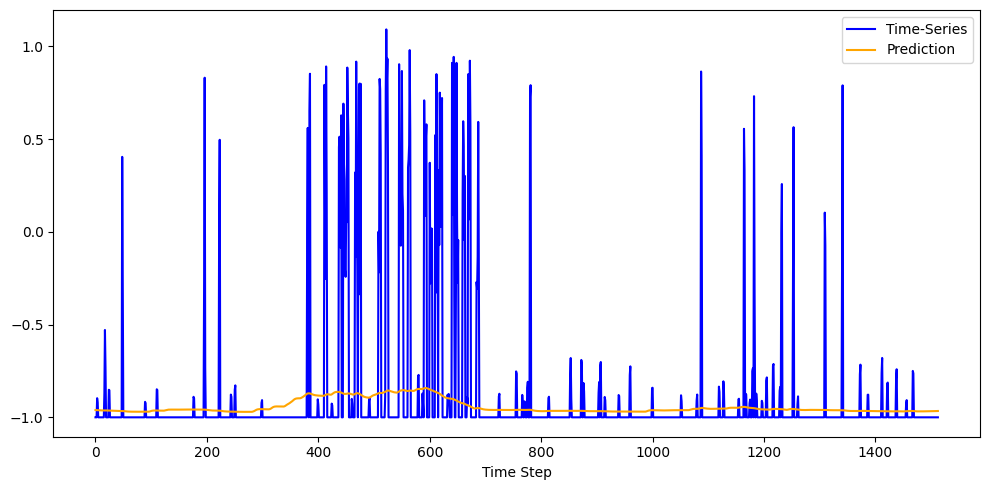

------------------
Art Signal Metrics
------------------
Precision: 0.292
Recall: 0.500
F1: 0.344



In [13]:
total_precision, total_recall, total_f1 = 0, 0, 0

for i, art_signal in enumerate(art_signals):
    X = art_signal["value"].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = art_signal["is_anomaly"].to_numpy()
    
    print("--------------")
    print(f"Art Signal {i + 1}")
    print("--------------")
    plot_signal(X, y)

    precision, recall, f1, = run_pipeline(X, y, **ART_HYPERPARAMS)
    total_precision += precision
    total_recall += recall
    total_f1 += f1

total_precision /= len(art_signals)
total_recall /= len(art_signals)
total_f1 /= len(art_signals)

print("------------------")
print("Art Signal Metrics")
print("------------------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

### **Ad Exchange**

In [14]:
ad_ex_signals = nab_download_subdataset(folder=AD_EX_FOLDER, file_names=AD_EX_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.

Finished downloading realAdExchange/!
---------------------
Total Signals: 6
Total Points: 9610
Total Anomaly Points: 960
Anomaly Rate: 9.99%


--------------
Ad Exchange Signal 1
--------------
Epoch   5 | Train Loss: 0.093347 | Val Loss: 0.260611
Epoch  10 | Train Loss: 0.091892 | Val Loss: 0.253484
Epoch  15 | Train Loss: 0.090441 | Val Loss: 0.239555
Early stopping at epoch 16

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


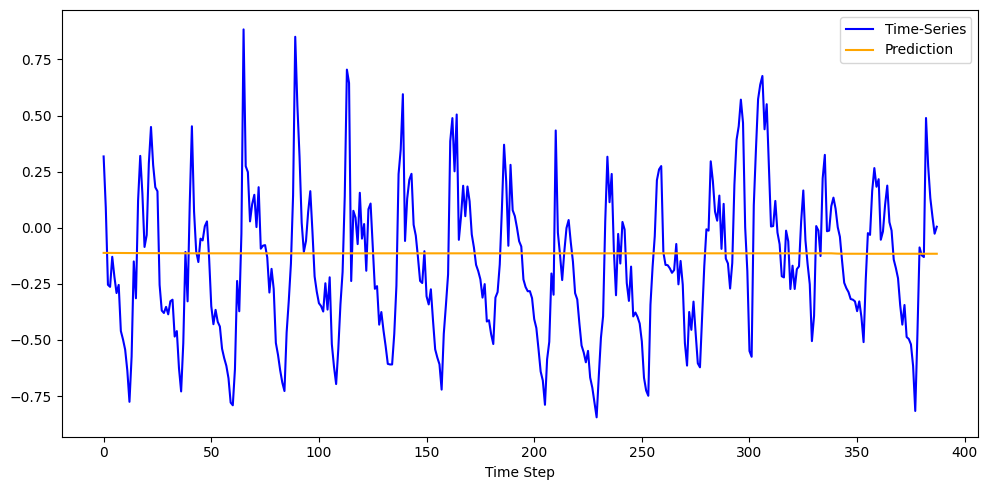

--------------
Ad Exchange Signal 2
--------------
Epoch   5 | Train Loss: 0.135006 | Val Loss: 0.279411
Epoch  10 | Train Loss: 0.134456 | Val Loss: 0.281845
Epoch  15 | Train Loss: 0.133940 | Val Loss: 0.278614
Early stopping at epoch 16

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


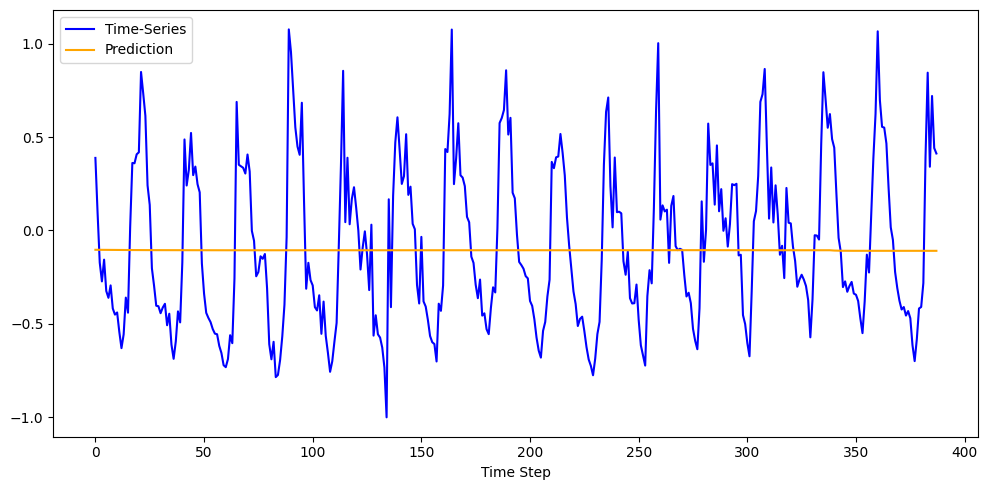

--------------
Ad Exchange Signal 3
--------------
Epoch   5 | Train Loss: 0.046289 | Val Loss: 0.066922
Epoch  10 | Train Loss: 0.031696 | Val Loss: 0.048106
Epoch  15 | Train Loss: 0.026969 | Val Loss: 0.045115
Epoch  20 | Train Loss: 0.025436 | Val Loss: 0.044370
Epoch  25 | Train Loss: 0.025418 | Val Loss: 0.044258
Epoch  30 | Train Loss: 0.025379 | Val Loss: 0.044732
Epoch  35 | Train Loss: 0.025284 | Val Loss: 0.045241
Epoch  40 | Train Loss: 0.025269 | Val Loss: 0.044984
Early stopping at epoch 40

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


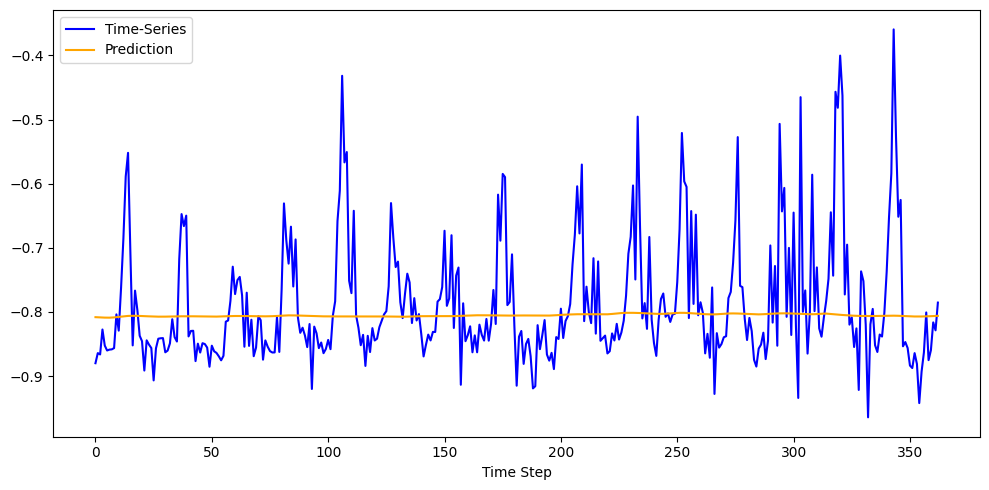

--------------
Ad Exchange Signal 4
--------------
Epoch   5 | Train Loss: 0.101637 | Val Loss: 0.051676
Epoch  10 | Train Loss: 0.043764 | Val Loss: 0.053317
Epoch  15 | Train Loss: 0.040321 | Val Loss: 0.050855
Epoch  20 | Train Loss: 0.038597 | Val Loss: 0.049099
Epoch  25 | Train Loss: 0.038465 | Val Loss: 0.049433
Epoch  30 | Train Loss: 0.038264 | Val Loss: 0.050303
Epoch  35 | Train Loss: 0.037941 | Val Loss: 0.048960
Epoch  40 | Train Loss: 0.037560 | Val Loss: 0.046290
Epoch  45 | Train Loss: 0.036528 | Val Loss: 0.045823
Epoch  50 | Train Loss: 0.035137 | Val Loss: 0.044610
Epoch  55 | Train Loss: 0.034593 | Val Loss: 0.044698
Epoch  60 | Train Loss: 0.033642 | Val Loss: 0.045388
Early stopping at epoch 61

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


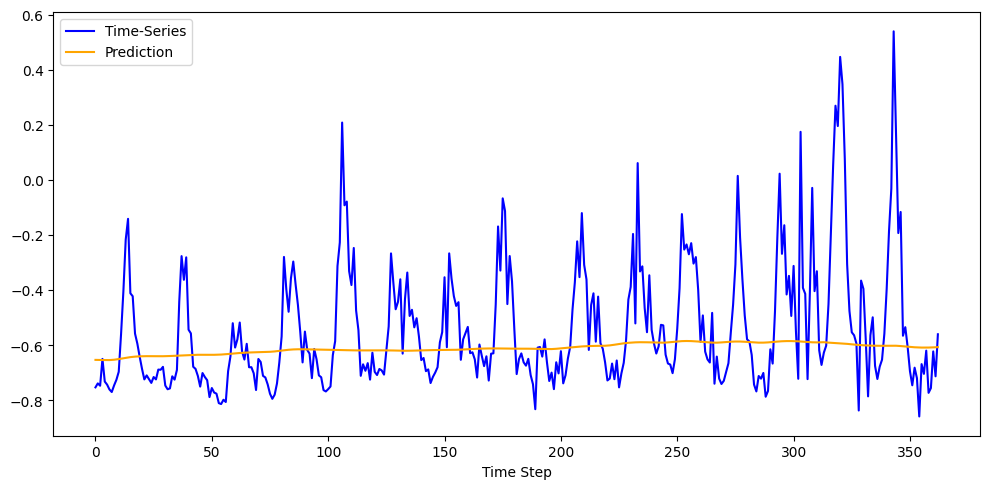

--------------
Ad Exchange Signal 5
--------------
Epoch   5 | Train Loss: 0.129252 | Val Loss: 0.021283
Epoch  10 | Train Loss: 0.027372 | Val Loss: 0.015159
Epoch  15 | Train Loss: 0.021558 | Val Loss: 0.009141
Epoch  20 | Train Loss: 0.014406 | Val Loss: 0.001916
Epoch  25 | Train Loss: 0.012563 | Val Loss: 0.000684
Epoch  30 | Train Loss: 0.012499 | Val Loss: 0.000691
Epoch  35 | Train Loss: 0.012501 | Val Loss: 0.000686
Early stopping at epoch 36

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


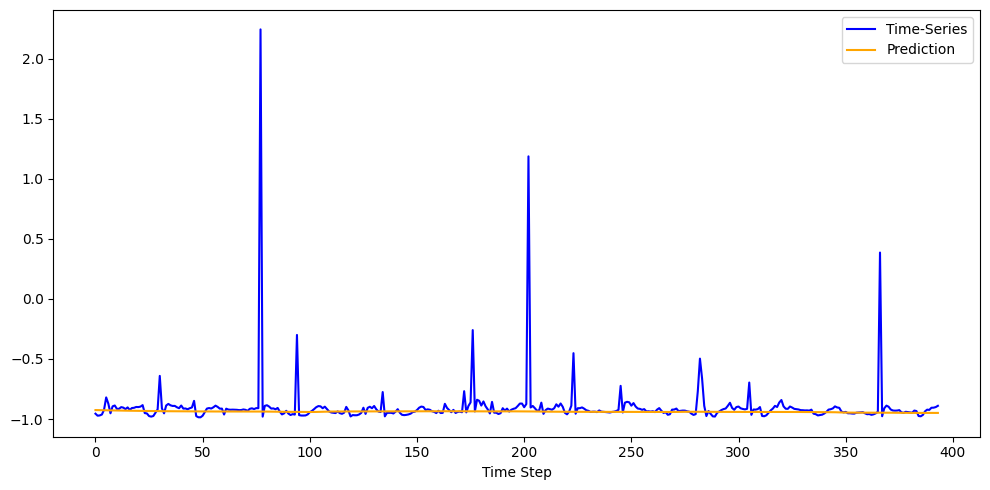

--------------
Ad Exchange Signal 6
--------------
Epoch   5 | Train Loss: 0.094822 | Val Loss: 0.018959
Epoch  10 | Train Loss: 0.026687 | Val Loss: 0.011693
Epoch  15 | Train Loss: 0.021851 | Val Loss: 0.006640
Epoch  20 | Train Loss: 0.017068 | Val Loss: 0.001855
Epoch  25 | Train Loss: 0.015866 | Val Loss: 0.001023
Epoch  30 | Train Loss: 0.015817 | Val Loss: 0.001002
Epoch  35 | Train Loss: 0.015788 | Val Loss: 0.001010
Early stopping at epoch 38

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


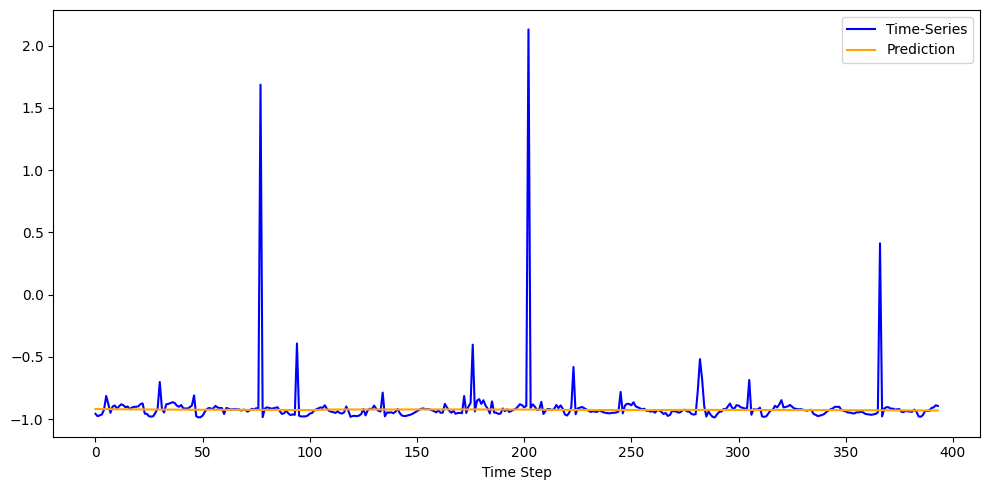

-------------------
Ad Exchange Metrics
-------------------
Precision: 0.500
Recall: 0.500
F1: 0.500



In [15]:
total_precision, total_recall, total_f1 = 0, 0, 0

for i, ad_ex_signal in enumerate(ad_ex_signals):
    X = ad_ex_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    # min-max normalization to [-1, 1]
    y = ad_ex_signal['is_anomaly'].to_numpy()
    
    print("--------------")
    print(f"Ad Exchange Signal {i + 1}")
    print("--------------")

    precision, recall, f1, = run_pipeline(X, y, **NAB_HYPERPARAMS)
    total_precision += precision
    total_recall += recall
    total_f1 += f1

total_precision /= len(ad_ex_signals)
total_recall /= len(ad_ex_signals)
total_f1 /= len(ad_ex_signals)

print("-------------------")
print("Ad Exchange Metrics")
print("-------------------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

### **AWS Cloudwatch**

In [16]:
aws_signals = nab_download_subdataset(folder=AWS_FOLDER, file_names=AWS_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.
Downloaded 10 .csv files.
Downloaded 15 .csv files.

Finished downloading realAWSCloudwatch/!
---------------------
Total Signals: 17
Total Points: 67740
Total Anomaly Points: 6312
Anomaly Rate: 9.32%


--------------
AWS Signal 1
--------------
Epoch   5 | Train Loss: 0.017555 | Val Loss: 0.016541
Epoch  10 | Train Loss: 0.012807 | Val Loss: 0.013546
Epoch  15 | Train Loss: 0.013005 | Val Loss: 0.013536
Epoch  20 | Train Loss: 0.012981 | Val Loss: 0.013535
Epoch  25 | Train Loss: 0.012849 | Val Loss: 0.013541
Early stopping at epoch 27

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


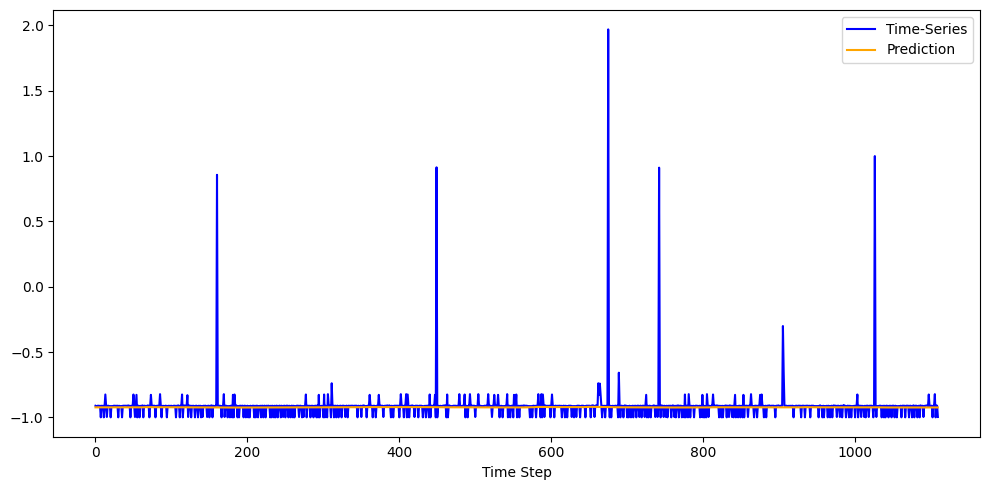

--------------
AWS Signal 2
--------------
Epoch   5 | Train Loss: 0.037798 | Val Loss: 0.053181
Epoch  10 | Train Loss: 0.036618 | Val Loss: 0.052680
Epoch  15 | Train Loss: 0.036594 | Val Loss: 0.052366
Epoch  20 | Train Loss: 0.036604 | Val Loss: 0.052434
Epoch  25 | Train Loss: 0.036475 | Val Loss: 0.051933
Epoch  30 | Train Loss: 0.036440 | Val Loss: 0.050784
Epoch  35 | Train Loss: 0.036176 | Val Loss: 0.048811
Epoch  40 | Train Loss: 0.036001 | Val Loss: 0.047710
Epoch  45 | Train Loss: 0.036121 | Val Loss: 0.047633
Epoch  50 | Train Loss: 0.036028 | Val Loss: 0.047474
Epoch  55 | Train Loss: 0.036036 | Val Loss: 0.047376
Early stopping at epoch 58

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


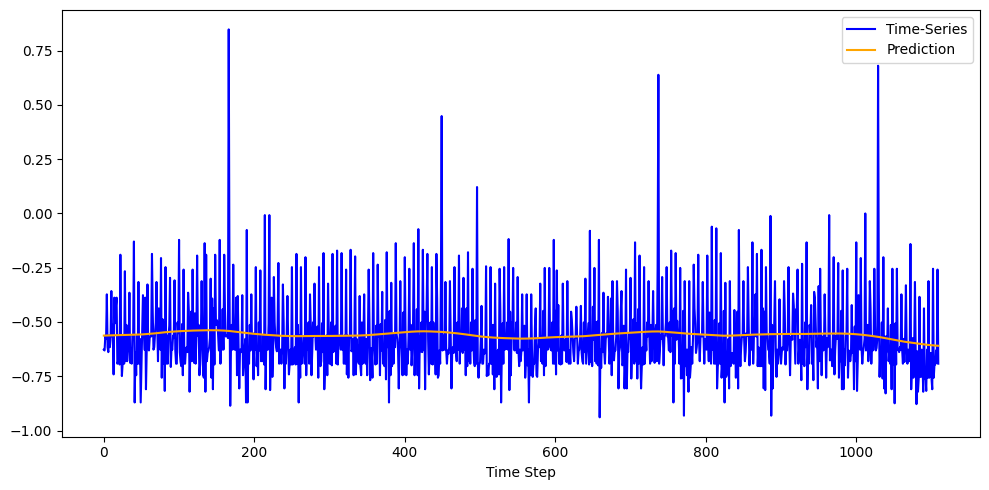

--------------
AWS Signal 3
--------------
Epoch   5 | Train Loss: 0.092781 | Val Loss: 0.067134
Epoch  10 | Train Loss: 0.082211 | Val Loss: 0.057867
Epoch  15 | Train Loss: 0.082397 | Val Loss: 0.057799
Epoch  20 | Train Loss: 0.082088 | Val Loss: 0.057974
Early stopping at epoch 22

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


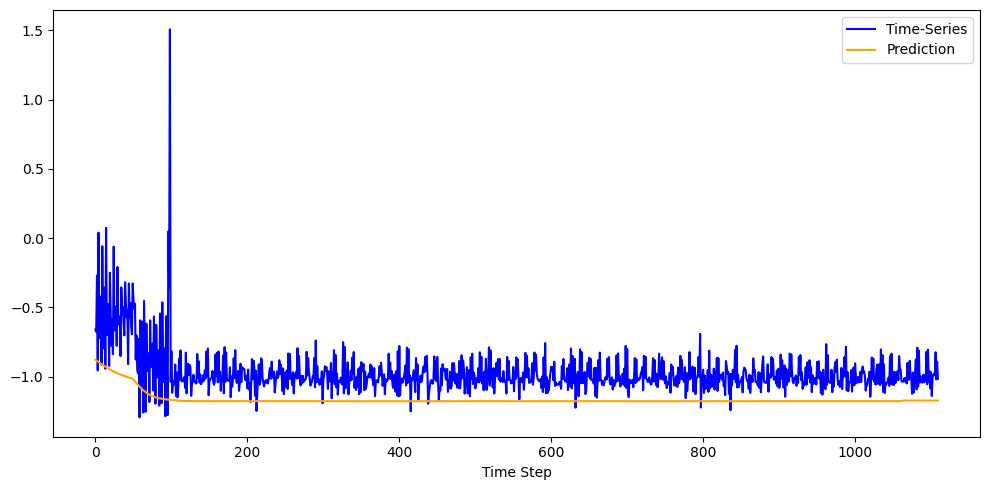

--------------
AWS Signal 4
--------------
Epoch   5 | Train Loss: 0.272214 | Val Loss: 0.622103
Epoch  10 | Train Loss: 0.251589 | Val Loss: 0.556092
Epoch  15 | Train Loss: 0.248534 | Val Loss: 0.543775
Epoch  20 | Train Loss: 0.242475 | Val Loss: 0.541671
Epoch  25 | Train Loss: 0.243527 | Val Loss: 0.540432
Epoch  30 | Train Loss: 0.244044 | Val Loss: 0.540183
Epoch  35 | Train Loss: 0.243401 | Val Loss: 0.539886
Epoch  40 | Train Loss: 0.244357 | Val Loss: 0.539787
Epoch  45 | Train Loss: 0.244061 | Val Loss: 0.538706
Epoch  50 | Train Loss: 0.242841 | Val Loss: 0.533087
Epoch  55 | Train Loss: 0.241448 | Val Loss: 0.527068
Epoch  60 | Train Loss: 0.234262 | Val Loss: 0.520493
Epoch  65 | Train Loss: 0.230867 | Val Loss: 0.508125
Epoch  70 | Train Loss: 0.229340 | Val Loss: 0.503065
Epoch  75 | Train Loss: 0.224590 | Val Loss: 0.501001
Epoch  80 | Train Loss: 0.221987 | Val Loss: 0.500390
Epoch  85 | Train Loss: 0.219025 | Val Loss: 0.506016
Epoch  90 | Train Loss: 0.212884 | Val 

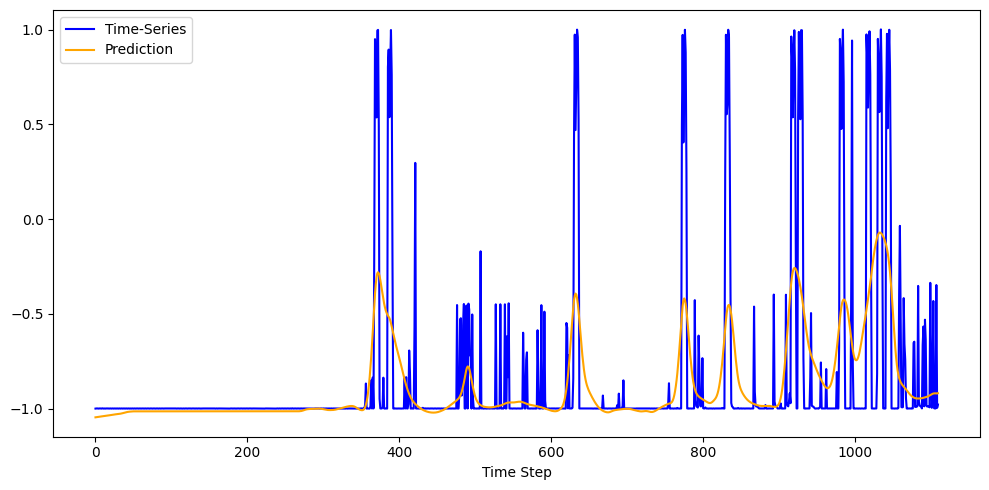

--------------
AWS Signal 5
--------------
Epoch   5 | Train Loss: 0.110861 | Val Loss: 0.008615
Epoch  10 | Train Loss: 0.065072 | Val Loss: 0.008697
Epoch  15 | Train Loss: 0.045774 | Val Loss: 0.011981
Epoch  20 | Train Loss: 0.043534 | Val Loss: 0.004363
Epoch  25 | Train Loss: 0.043192 | Val Loss: 0.010514
Epoch  30 | Train Loss: 0.045409 | Val Loss: 0.011517
Early stopping at epoch 34

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


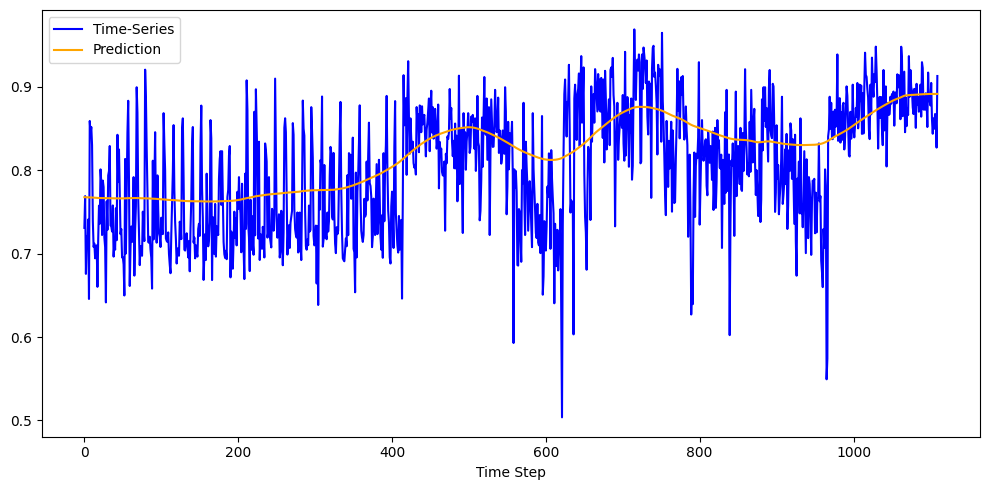

--------------
AWS Signal 6
--------------
Epoch   5 | Train Loss: 0.049006 | Val Loss: 0.007228
Epoch  10 | Train Loss: 0.035173 | Val Loss: 0.005059
Epoch  15 | Train Loss: 0.031168 | Val Loss: 0.004985
Epoch  20 | Train Loss: 0.026460 | Val Loss: 0.005072
Early stopping at epoch 21

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


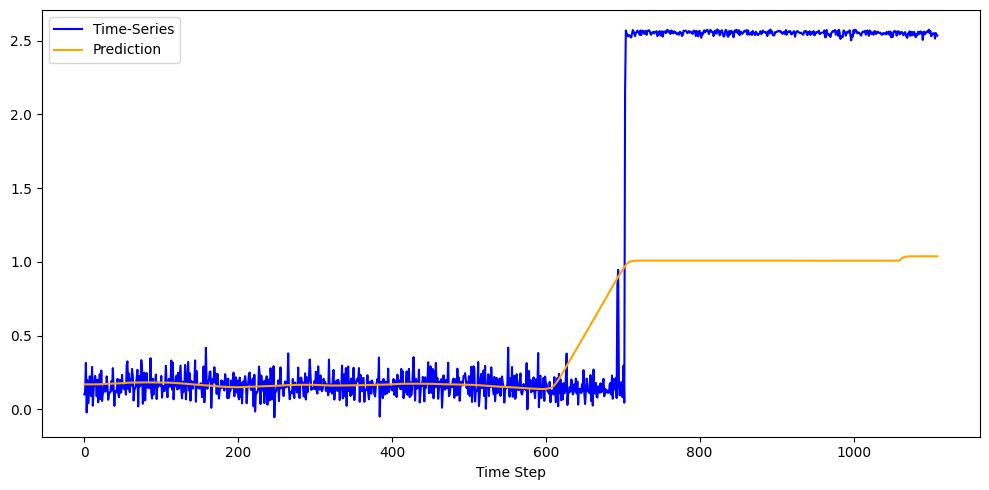

--------------
AWS Signal 7
--------------
Epoch   5 | Train Loss: 0.019748 | Val Loss: 0.020858
Epoch  10 | Train Loss: 0.013065 | Val Loss: 0.015858
Epoch  15 | Train Loss: 0.013055 | Val Loss: 0.015847
Epoch  20 | Train Loss: 0.012930 | Val Loss: 0.015847
Early stopping at epoch 22

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


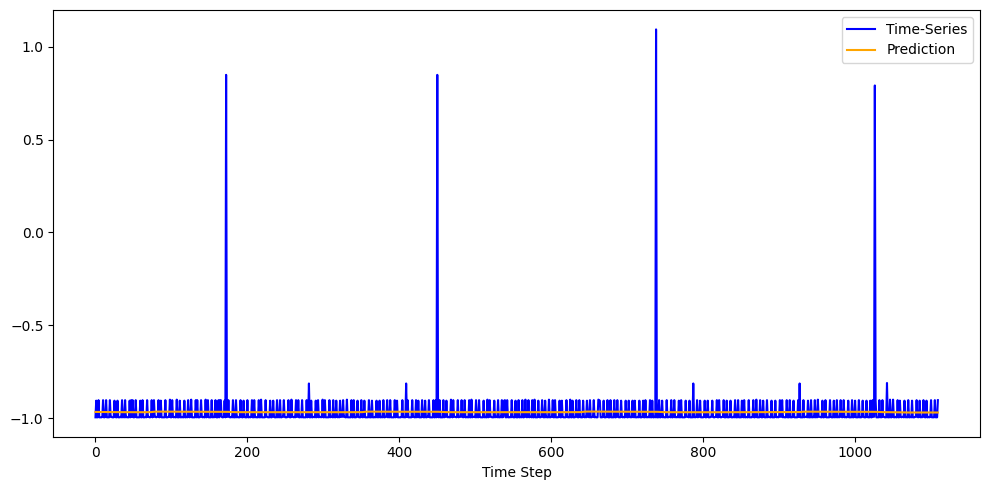

--------------
AWS Signal 8
--------------
Epoch   5 | Train Loss: 0.068000 | Val Loss: 0.010562
Epoch  10 | Train Loss: 0.062466 | Val Loss: 0.003424
Epoch  15 | Train Loss: 0.062198 | Val Loss: 0.003272
Epoch  20 | Train Loss: 0.060876 | Val Loss: 0.000541
Epoch  25 | Train Loss: 0.058464 | Val Loss: 0.000193
Epoch  30 | Train Loss: 0.058222 | Val Loss: 0.000181
Epoch  35 | Train Loss: 0.058760 | Val Loss: 0.000935
Early stopping at epoch 39

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


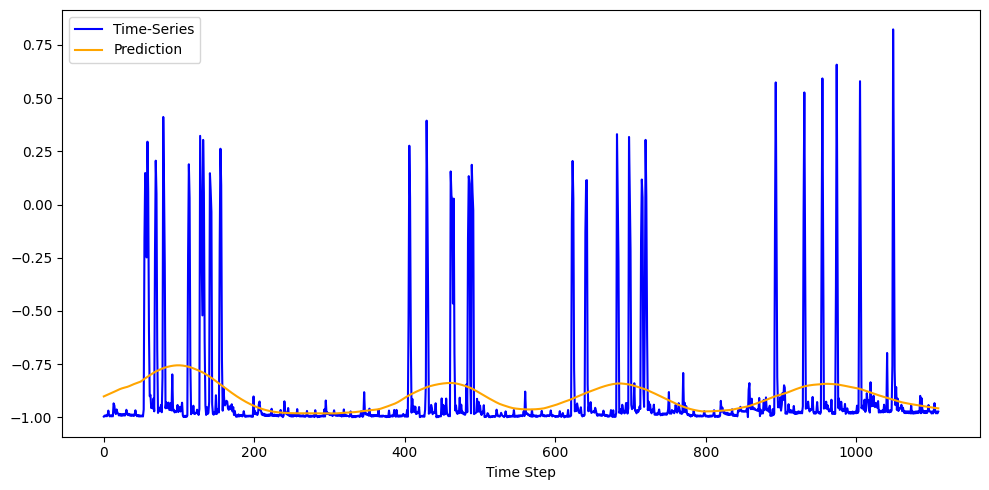

--------------
AWS Signal 9
--------------
Epoch   5 | Train Loss: 0.020960 | Val Loss: 0.065836
Epoch  10 | Train Loss: 0.015852 | Val Loss: 0.063561
Epoch  15 | Train Loss: 0.015858 | Val Loss: 0.063314
Epoch  20 | Train Loss: 0.015758 | Val Loss: 0.062998
Epoch  25 | Train Loss: 0.015686 | Val Loss: 0.062810
Epoch  30 | Train Loss: 0.015456 | Val Loss: 0.062197
Epoch  35 | Train Loss: 0.014993 | Val Loss: 0.061511
Epoch  40 | Train Loss: 0.014931 | Val Loss: 0.061509
Epoch  45 | Train Loss: 0.014932 | Val Loss: 0.061483
Early stopping at epoch 49

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


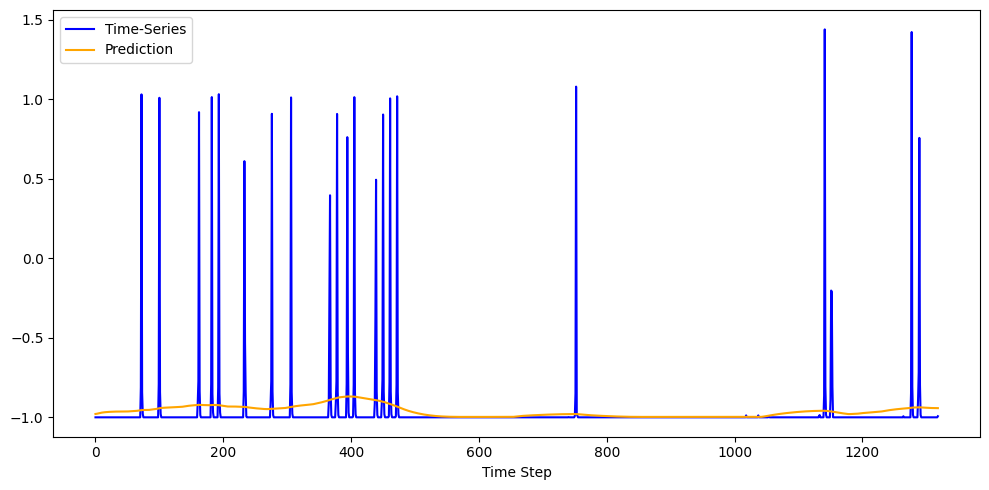

--------------
AWS Signal 10
--------------
Epoch   5 | Train Loss: 0.036578 | Val Loss: 0.127772
Epoch  10 | Train Loss: 0.029420 | Val Loss: 0.122951
Epoch  15 | Train Loss: 0.029174 | Val Loss: 0.122231
Epoch  20 | Train Loss: 0.028819 | Val Loss: 0.122239
Epoch  25 | Train Loss: 0.029071 | Val Loss: 0.121704
Epoch  30 | Train Loss: 0.028940 | Val Loss: 0.118273
Epoch  35 | Train Loss: 0.027985 | Val Loss: 0.113830
Epoch  40 | Train Loss: 0.028059 | Val Loss: 0.113150
Epoch  45 | Train Loss: 0.027973 | Val Loss: 0.113176
Epoch  50 | Train Loss: 0.027856 | Val Loss: 0.112699
Epoch  55 | Train Loss: 0.028209 | Val Loss: 0.112611
Early stopping at epoch 57

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


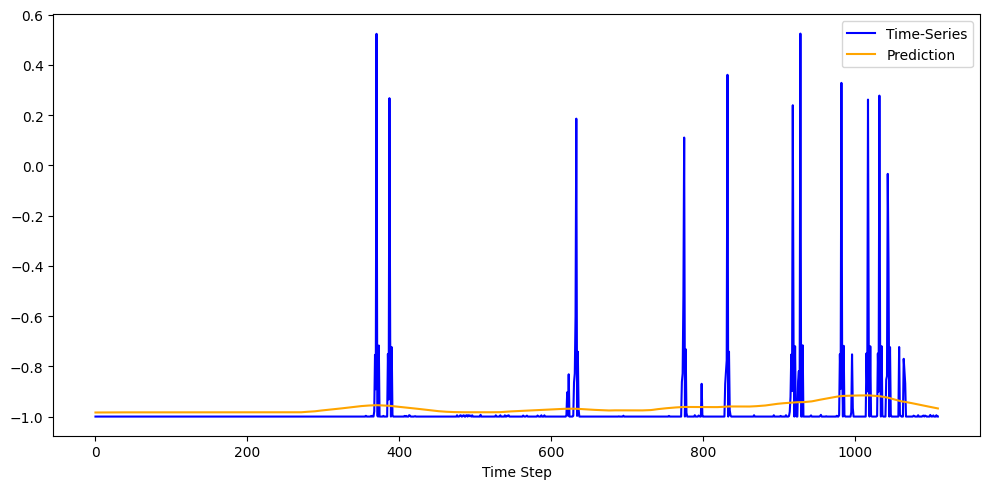

--------------
AWS Signal 11
--------------
Epoch   5 | Train Loss: 0.010118 | Val Loss: 0.006053
Epoch  10 | Train Loss: 0.002570 | Val Loss: 0.000066
Epoch  15 | Train Loss: 0.002472 | Val Loss: 0.000039
Epoch  20 | Train Loss: 0.002397 | Val Loss: 0.000012
Early stopping at epoch 22

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


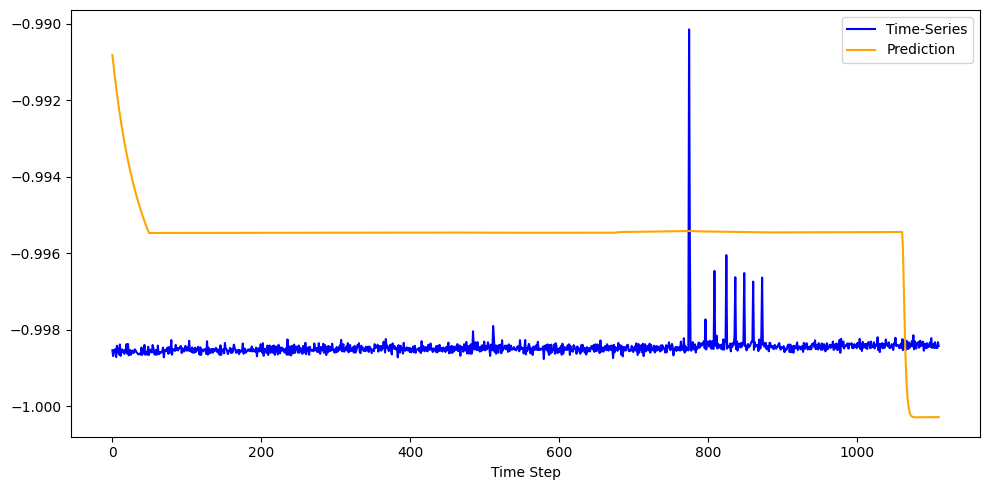

--------------
AWS Signal 12
--------------
Epoch   5 | Train Loss: 0.058052 | Val Loss: 0.087406
Epoch  10 | Train Loss: 0.051286 | Val Loss: 0.082582
Epoch  15 | Train Loss: 0.051171 | Val Loss: 0.082425
Epoch  20 | Train Loss: 0.050608 | Val Loss: 0.081816
Epoch  25 | Train Loss: 0.049523 | Val Loss: 0.080934
Epoch  30 | Train Loss: 0.049482 | Val Loss: 0.080890
Epoch  35 | Train Loss: 0.049401 | Val Loss: 0.080926
Epoch  40 | Train Loss: 0.049362 | Val Loss: 0.080825
Epoch  45 | Train Loss: 0.049265 | Val Loss: 0.080772
Early stopping at epoch 48

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


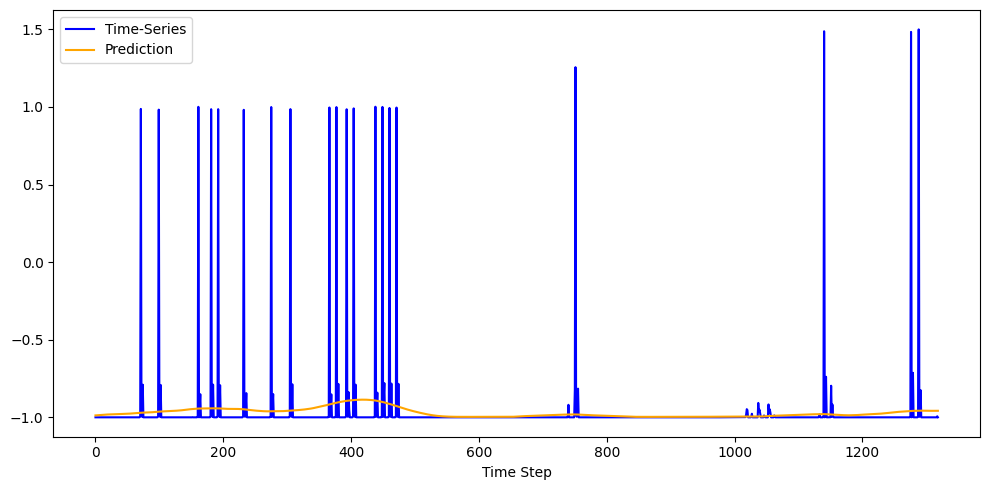

--------------
AWS Signal 13
--------------
Epoch   5 | Train Loss: 0.093081 | Val Loss: 0.074803
Epoch  10 | Train Loss: 0.088249 | Val Loss: 0.066027
Epoch  15 | Train Loss: 0.086040 | Val Loss: 0.066396
Epoch  20 | Train Loss: 0.085943 | Val Loss: 0.066112
Epoch  25 | Train Loss: 0.085579 | Val Loss: 0.065515
Epoch  30 | Train Loss: 0.085676 | Val Loss: 0.065361
Epoch  35 | Train Loss: 0.085660 | Val Loss: 0.065212
Epoch  40 | Train Loss: 0.085574 | Val Loss: 0.065210
Epoch  45 | Train Loss: 0.085438 | Val Loss: 0.065235
Epoch  50 | Train Loss: 0.085088 | Val Loss: 0.065529
Early stopping at epoch 50

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


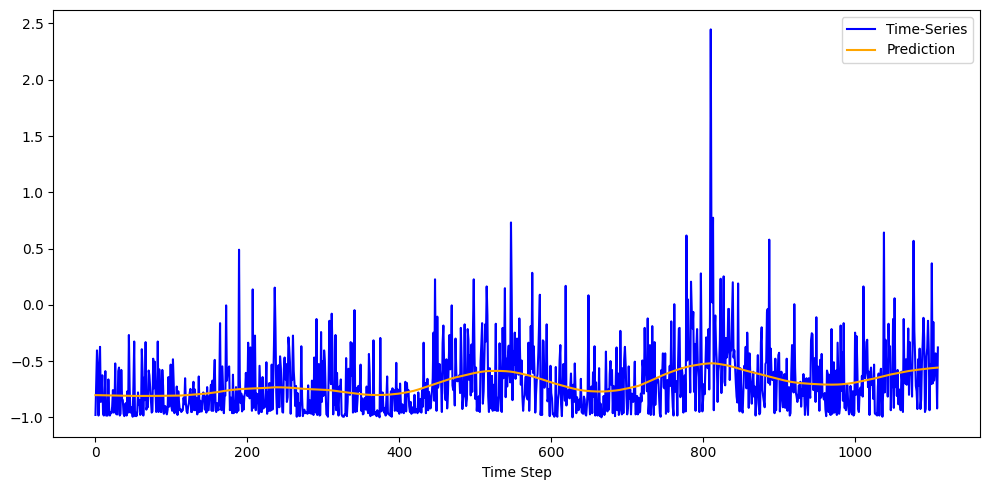

--------------
AWS Signal 14
--------------
Epoch   5 | Train Loss: 0.006766 | Val Loss: 0.010869
Epoch  10 | Train Loss: 0.006748 | Val Loss: 0.010840
Epoch  15 | Train Loss: 0.006740 | Val Loss: 0.010820
Early stopping at epoch 19

Metrics
-------
Precision = 0.5000
Recall = 1.0000
F1 = 0.6667


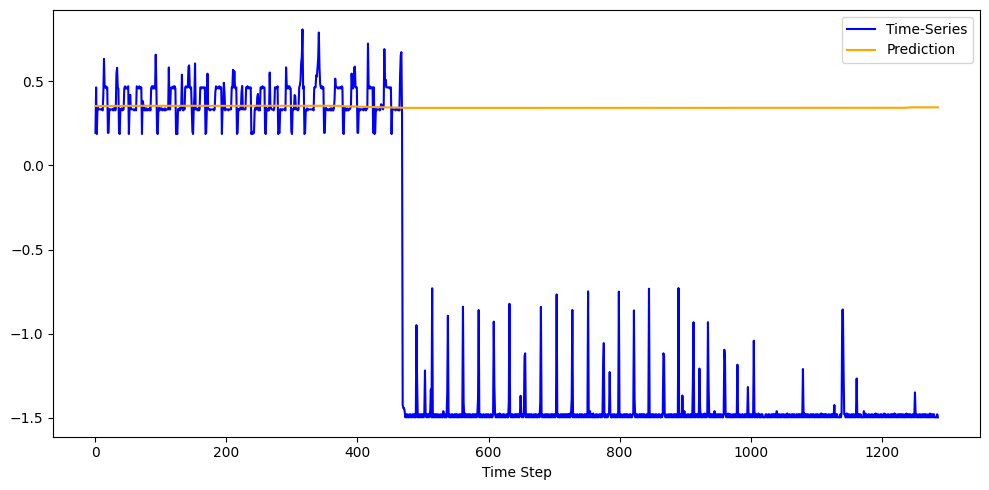

--------------
AWS Signal 15
--------------
Epoch   5 | Train Loss: 0.119548 | Val Loss: 0.059811
Epoch  10 | Train Loss: 0.031769 | Val Loss: 0.011925
Epoch  15 | Train Loss: 0.026519 | Val Loss: 0.008306
Epoch  20 | Train Loss: 0.021898 | Val Loss: 0.004346
Epoch  25 | Train Loss: 0.019589 | Val Loss: 0.002955
Epoch  30 | Train Loss: 0.020868 | Val Loss: 0.002841
Epoch  35 | Train Loss: 0.019727 | Val Loss: 0.002543
Early stopping at epoch 38

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


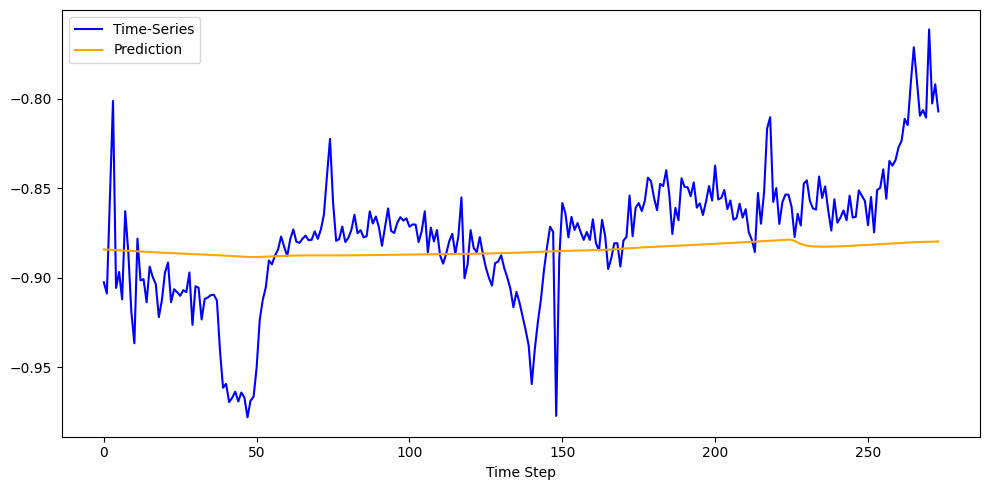

--------------
AWS Signal 16
--------------
Epoch   5 | Train Loss: 0.064365 | Val Loss: 0.062495
Epoch  10 | Train Loss: 0.064156 | Val Loss: 0.061491
Epoch  15 | Train Loss: 0.061897 | Val Loss: 0.058413
Epoch  20 | Train Loss: 0.061670 | Val Loss: 0.058191
Epoch  25 | Train Loss: 0.061614 | Val Loss: 0.058415
Early stopping at epoch 29

Metrics
-------
Precision = 1.0000
Recall = 0.5000
F1 = 0.6667


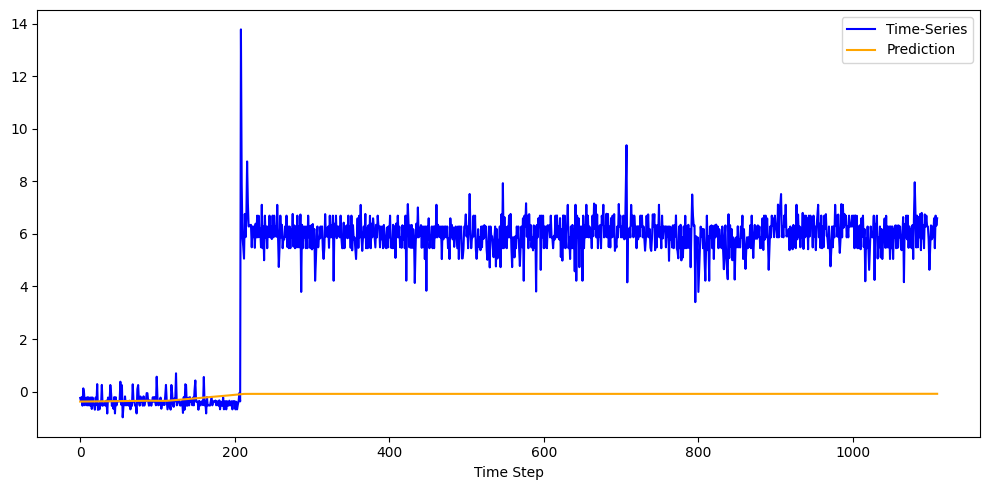

--------------
AWS Signal 17
--------------
Epoch   5 | Train Loss: 0.008289 | Val Loss: 0.066758
Epoch  10 | Train Loss: 0.004485 | Val Loss: 0.061022
Epoch  15 | Train Loss: 0.004146 | Val Loss: 0.051302
Epoch  20 | Train Loss: 0.003542 | Val Loss: 0.033000
Epoch  25 | Train Loss: 0.003084 | Val Loss: 0.024546
Epoch  30 | Train Loss: 0.003060 | Val Loss: 0.024140
Epoch  35 | Train Loss: 0.003241 | Val Loss: 0.024821
Early stopping at epoch 38

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


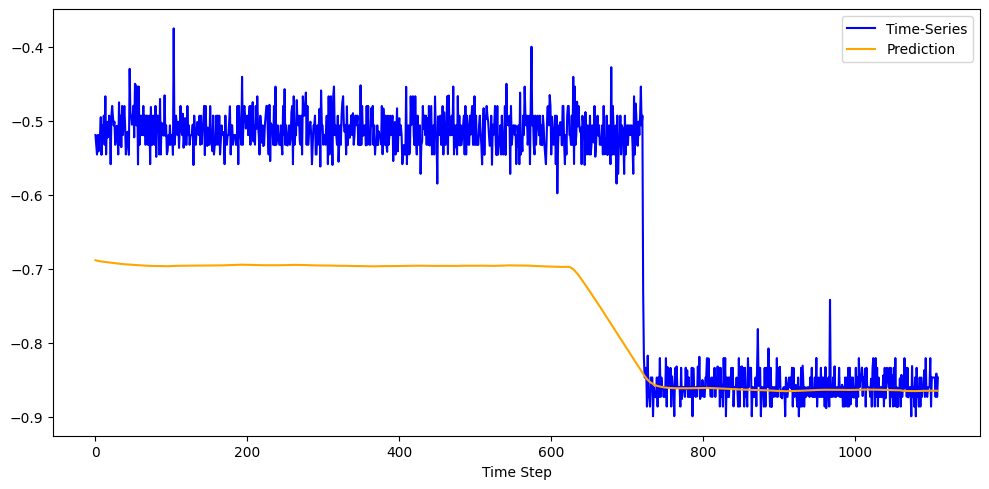

----------------------
AWS Cloudwatch Metrics
----------------------
Precision: 0.382
Recall: 0.382
F1: 0.373



In [17]:
total_precision, total_recall, total_f1 = 0, 0, 0

for i, aws_signal in enumerate(aws_signals):
    X = aws_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = aws_signal['is_anomaly'].to_numpy()
    
    print("--------------")
    print(f"AWS Signal {i + 1}")
    print("--------------")

    precision, recall, f1, = run_pipeline(X, y, **NAB_HYPERPARAMS)
    total_precision += precision
    total_recall += recall
    total_f1 += f1

total_precision /= len(aws_signals)
total_recall /= len(aws_signals)
total_f1 /= len(aws_signals)

print("----------------------")
print("AWS Cloudwatch Metrics")
print("----------------------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

### **Real Traffic**

In [18]:
traffic_signals = nab_download_subdataset(folder=TRAFFIC_FOLDER, file_names=TRAFFIC_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.

Finished downloading realTraffic/!
---------------------
Total Signals: 7
Total Points: 15664
Total Anomaly Points: 1560
Anomaly Rate: 9.96%


--------------
Traffic Signal 1
--------------
Epoch   5 | Train Loss: 0.024809 | Val Loss: 0.064133
Epoch  10 | Train Loss: 0.014855 | Val Loss: 0.054610
Epoch  15 | Train Loss: 0.014613 | Val Loss: 0.056472
Epoch  20 | Train Loss: 0.014575 | Val Loss: 0.055360
Epoch  25 | Train Loss: 0.014555 | Val Loss: 0.056554
Early stopping at epoch 25

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


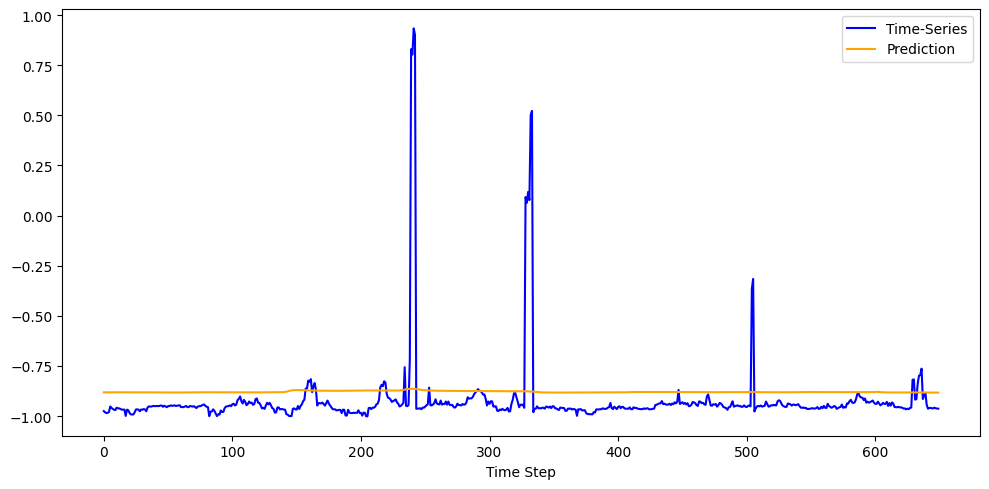

--------------
Traffic Signal 2
--------------
Epoch   5 | Train Loss: 0.048187 | Val Loss: 0.029143
Epoch  10 | Train Loss: 0.038577 | Val Loss: 0.018542
Epoch  15 | Train Loss: 0.033810 | Val Loss: 0.014022
Epoch  20 | Train Loss: 0.033456 | Val Loss: 0.014266
Epoch  25 | Train Loss: 0.033565 | Val Loss: 0.014508
Epoch  30 | Train Loss: 0.033446 | Val Loss: 0.014204
Early stopping at epoch 32

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


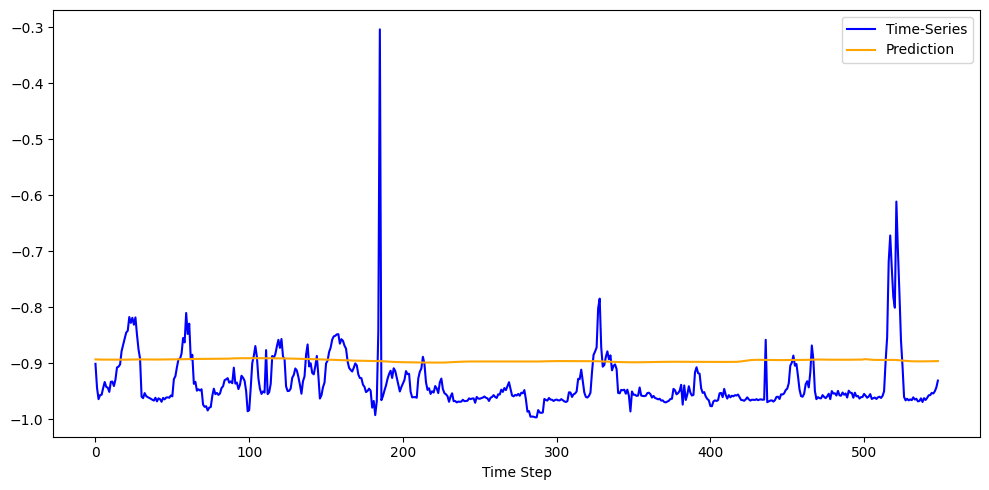

--------------
Traffic Signal 3
--------------
Epoch   5 | Train Loss: 0.091464 | Val Loss: 0.108131
Epoch  10 | Train Loss: 0.088080 | Val Loss: 0.105789
Epoch  15 | Train Loss: 0.087416 | Val Loss: 0.105925
Epoch  20 | Train Loss: 0.086817 | Val Loss: 0.106557
Epoch  25 | Train Loss: 0.081210 | Val Loss: 0.102938
Epoch  30 | Train Loss: 0.080496 | Val Loss: 0.103216
Epoch  35 | Train Loss: 0.080162 | Val Loss: 0.102753
Epoch  40 | Train Loss: 0.080075 | Val Loss: 0.102814
Epoch  45 | Train Loss: 0.079764 | Val Loss: 0.102552
Epoch  50 | Train Loss: 0.079501 | Val Loss: 0.103308
Epoch  55 | Train Loss: 0.079135 | Val Loss: 0.103462
Epoch  60 | Train Loss: 0.078939 | Val Loss: 0.102730
Early stopping at epoch 62

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


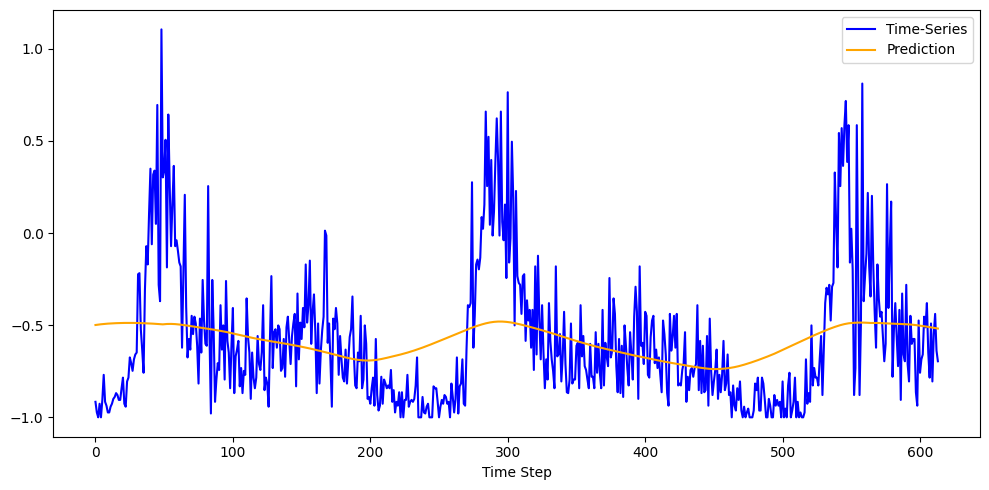

--------------
Traffic Signal 4
--------------
Epoch   5 | Train Loss: 0.097091 | Val Loss: 0.096646
Epoch  10 | Train Loss: 0.093133 | Val Loss: 0.091358
Epoch  15 | Train Loss: 0.081294 | Val Loss: 0.076824
Epoch  20 | Train Loss: 0.079532 | Val Loss: 0.074902
Epoch  25 | Train Loss: 0.077560 | Val Loss: 0.072023
Epoch  30 | Train Loss: 0.076631 | Val Loss: 0.071704
Epoch  35 | Train Loss: 0.076335 | Val Loss: 0.071216
Epoch  40 | Train Loss: 0.072803 | Val Loss: 0.066208
Epoch  45 | Train Loss: 0.070076 | Val Loss: 0.064393
Epoch  50 | Train Loss: 0.063043 | Val Loss: 0.050308
Epoch  55 | Train Loss: 0.061449 | Val Loss: 0.050322
Epoch  60 | Train Loss: 0.060961 | Val Loss: 0.048536
Epoch  65 | Train Loss: 0.058741 | Val Loss: 0.047192
Epoch  70 | Train Loss: 0.058555 | Val Loss: 0.046412
Epoch  75 | Train Loss: 0.056561 | Val Loss: 0.043826
Epoch  80 | Train Loss: 0.055348 | Val Loss: 0.041225
Epoch  85 | Train Loss: 0.055128 | Val Loss: 0.041848
Epoch  90 | Train Loss: 0.054024 | 

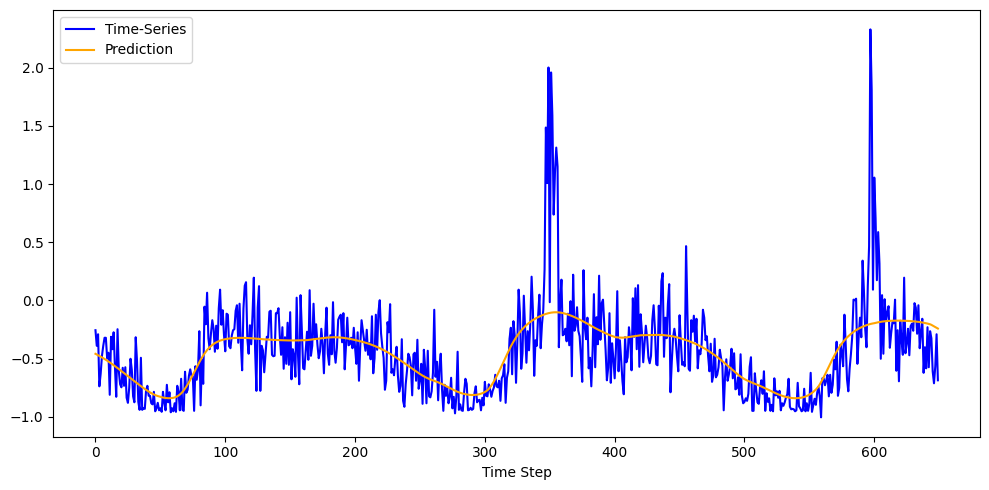

--------------
Traffic Signal 5
--------------
Epoch   5 | Train Loss: 0.066057 | Val Loss: 0.046373
Epoch  10 | Train Loss: 0.065661 | Val Loss: 0.045913
Epoch  15 | Train Loss: 0.065380 | Val Loss: 0.045810
Epoch  20 | Train Loss: 0.063037 | Val Loss: 0.045189
Epoch  25 | Train Loss: 0.062917 | Val Loss: 0.045038
Epoch  30 | Train Loss: 0.062798 | Val Loss: 0.044964
Early stopping at epoch 34

Metrics
-------
Precision = 0.3333
Recall = 1.0000
F1 = 0.5000


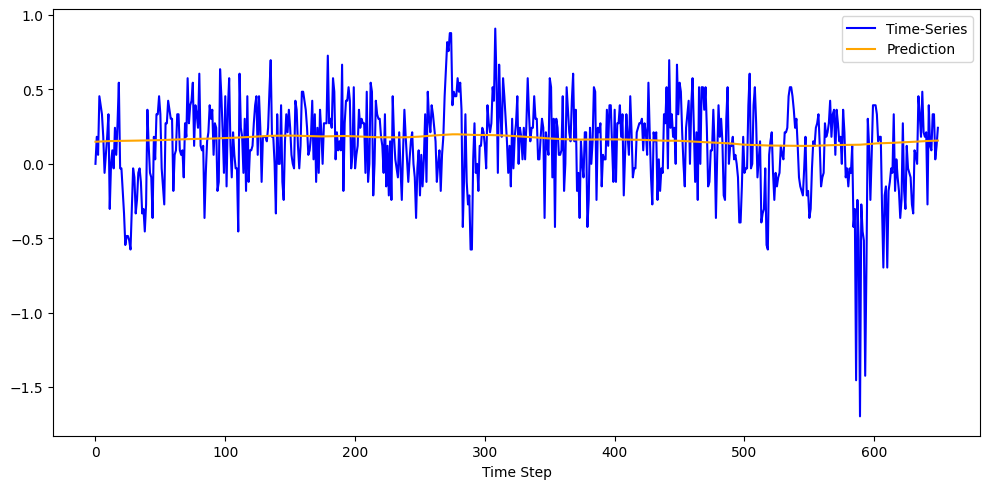

--------------
Traffic Signal 6
--------------
Epoch   5 | Train Loss: 0.021003 | Val Loss: 0.099626
Epoch  10 | Train Loss: 0.023709 | Val Loss: 0.098361
Epoch  15 | Train Loss: 0.021543 | Val Loss: 0.097479
Early stopping at epoch 16

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


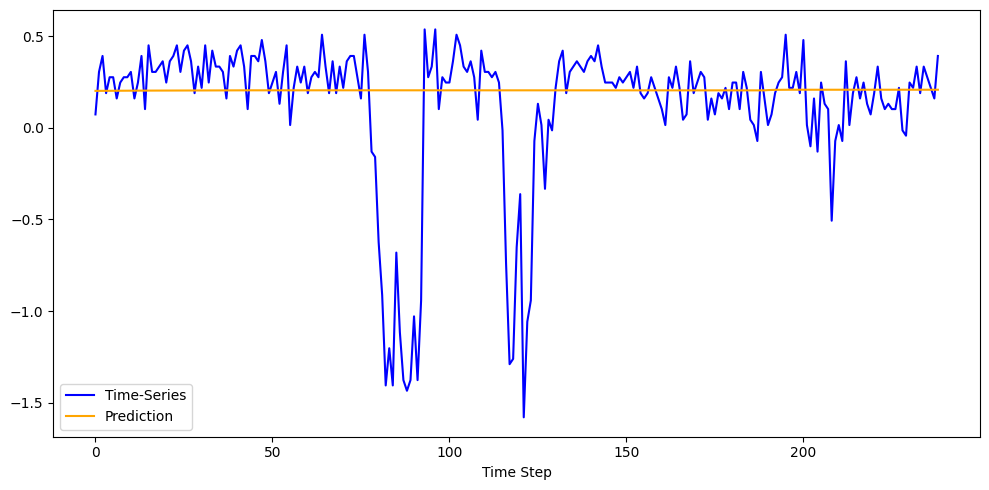

--------------
Traffic Signal 7
--------------
Epoch   5 | Train Loss: 0.034802 | Val Loss: 0.026953
Epoch  10 | Train Loss: 0.032450 | Val Loss: 0.024601
Epoch  15 | Train Loss: 0.029928 | Val Loss: 0.023142
Epoch  20 | Train Loss: 0.027577 | Val Loss: 0.022440
Epoch  25 | Train Loss: 0.027294 | Val Loss: 0.022431
Epoch  30 | Train Loss: 0.027261 | Val Loss: 0.022427
Early stopping at epoch 33

Metrics
-------
Precision = 0.5000
Recall = 0.5000
F1 = 0.5000


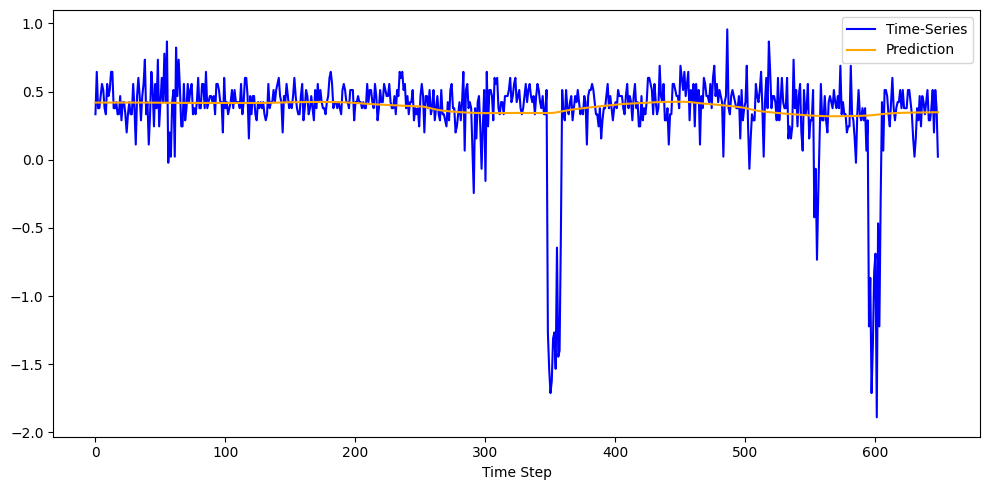

--------------------
Real Traffic Metrics
--------------------
Precision: 0.405
Recall: 0.429
F1: 0.381



In [19]:
total_precision, total_recall, total_f1 = 0, 0, 0

for i, traffic_signal in enumerate(traffic_signals):
    X = traffic_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = traffic_signal['is_anomaly'].to_numpy()

    print("--------------")
    print(f"Traffic Signal {i + 1}")
    print("--------------")

    precision, recall, f1, = run_pipeline(X, y, **NAB_HYPERPARAMS)
    total_precision += precision
    total_recall += recall
    total_f1 += f1

total_precision /= len(traffic_signals)
total_recall /= len(traffic_signals)
total_f1 /= len(traffic_signals)

print("--------------------")
print("Real Traffic Metrics")
print("--------------------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

### **Twitter**

In [20]:
twitter_signals = nab_download_subdataset(folder=TWEETS_FOLDER, file_names=TWEETS_FILE_NAMES, nab_labels=nab_labels)

Downloaded 5 .csv files.
Downloaded 10 .csv files.

Finished downloading realTweets/!
---------------------
Total Signals: 10
Total Points: 158631
Total Anomaly Points: 15651
Anomaly Rate: 9.87%


--------------
Twitter Signal 1
--------------
Epoch   5 | Train Loss: 0.001950 | Val Loss: 0.000310
Epoch  10 | Train Loss: 0.001947 | Val Loss: 0.000309
Epoch  15 | Train Loss: 0.001944 | Val Loss: 0.000308
Early stopping at epoch 17

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


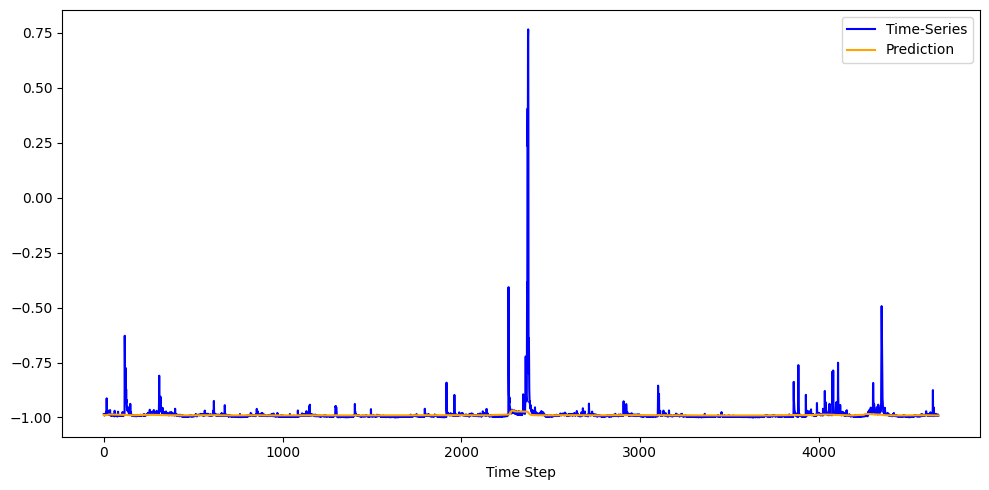

--------------
Twitter Signal 2
--------------
Epoch   5 | Train Loss: 0.001441 | Val Loss: 0.001088
Epoch  10 | Train Loss: 0.001426 | Val Loss: 0.001052
Epoch  15 | Train Loss: 0.001401 | Val Loss: 0.001048
Early stopping at epoch 17

Metrics
-------
Precision = 0.2000
Recall = 1.0000
F1 = 0.3333


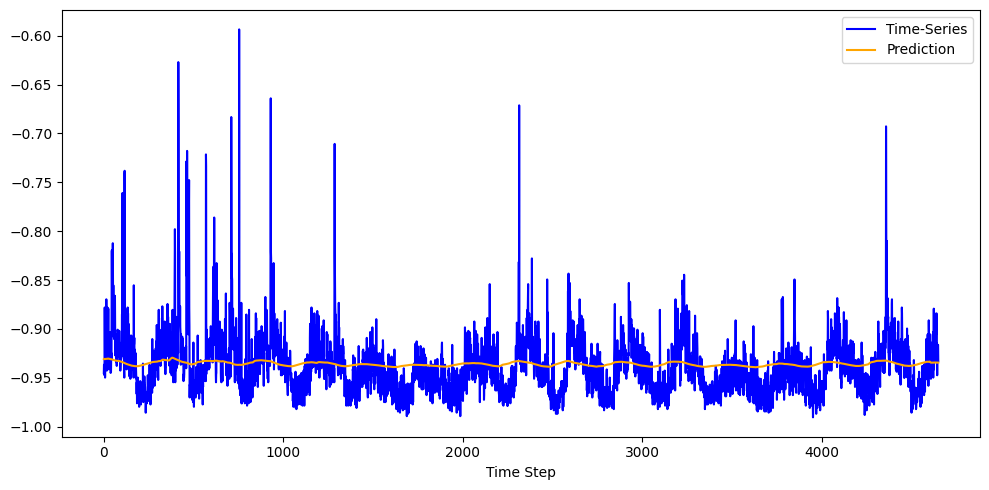

--------------
Twitter Signal 3
--------------
Epoch   5 | Train Loss: 0.002387 | Val Loss: 0.000958
Epoch  10 | Train Loss: 0.002129 | Val Loss: 0.000793
Epoch  15 | Train Loss: 0.001938 | Val Loss: 0.000734
Early stopping at epoch 17

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


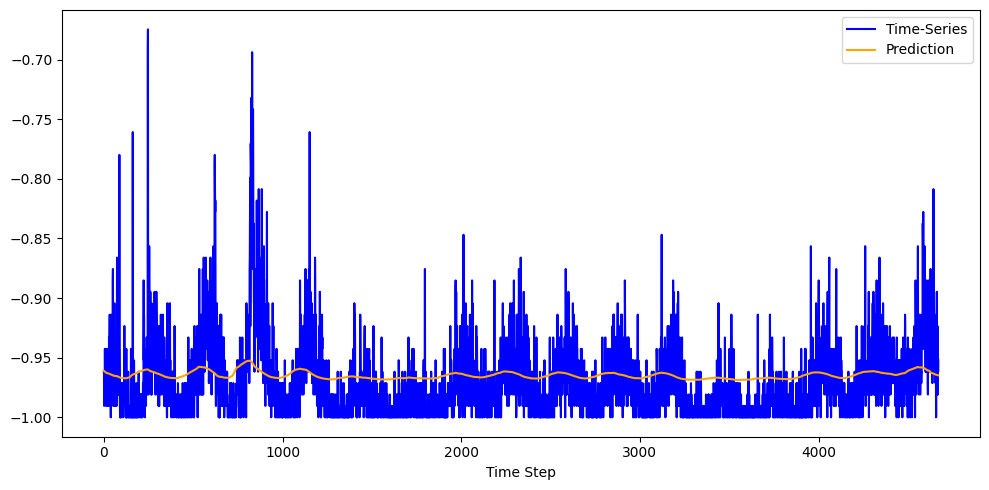

--------------
Twitter Signal 4
--------------
Epoch   5 | Train Loss: 0.001758 | Val Loss: 0.001161
Epoch  10 | Train Loss: 0.001755 | Val Loss: 0.001128
Epoch  15 | Train Loss: 0.001754 | Val Loss: 0.001132
Early stopping at epoch 17

Metrics
-------
Precision = 0.5000
Recall = 1.0000
F1 = 0.6667


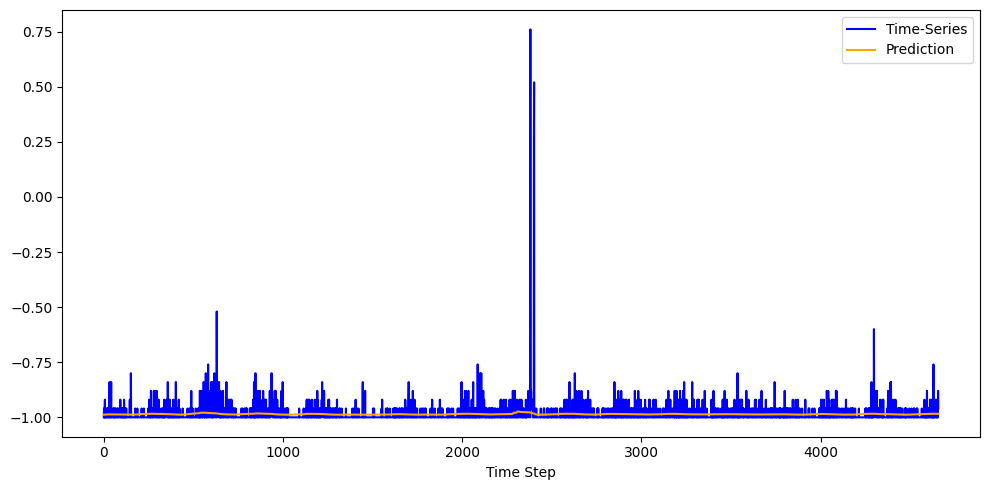

--------------
Twitter Signal 5
--------------
Epoch   5 | Train Loss: 0.002604 | Val Loss: 0.013142
Epoch  10 | Train Loss: 0.001963 | Val Loss: 0.012628
Epoch  15 | Train Loss: 0.001911 | Val Loss: 0.012577
Epoch  20 | Train Loss: 0.001894 | Val Loss: 0.012525
Early stopping at epoch 23

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


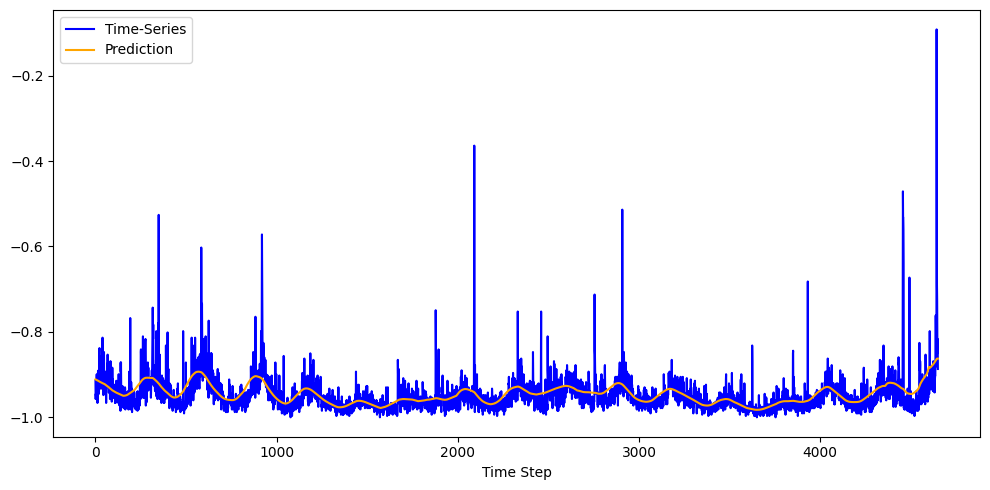

--------------
Twitter Signal 6
--------------
Epoch   5 | Train Loss: 0.006276 | Val Loss: 0.013030
Epoch  10 | Train Loss: 0.006174 | Val Loss: 0.012012
Epoch  15 | Train Loss: 0.005228 | Val Loss: 0.008731
Epoch  20 | Train Loss: 0.005166 | Val Loss: 0.008644
Epoch  25 | Train Loss: 0.005130 | Val Loss: 0.008631
Early stopping at epoch 29

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


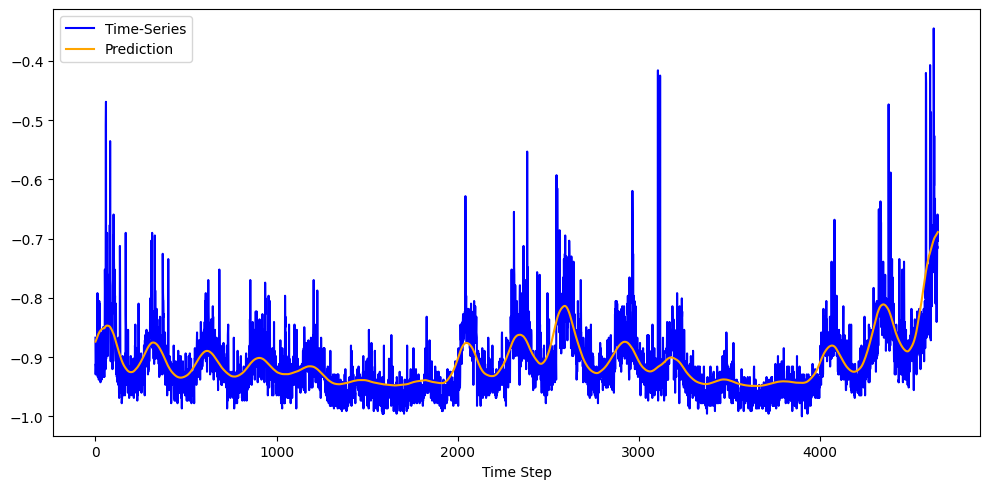

--------------
Twitter Signal 7
--------------
Epoch   5 | Train Loss: 0.007489 | Val Loss: 0.013089
Epoch  10 | Train Loss: 0.006994 | Val Loss: 0.012812
Epoch  15 | Train Loss: 0.006896 | Val Loss: 0.012687
Epoch  20 | Train Loss: 0.006865 | Val Loss: 0.012672
Epoch  25 | Train Loss: 0.006838 | Val Loss: 0.012679
Early stopping at epoch 26

Metrics
-------
Precision = 0.2500
Recall = 1.0000
F1 = 0.4000


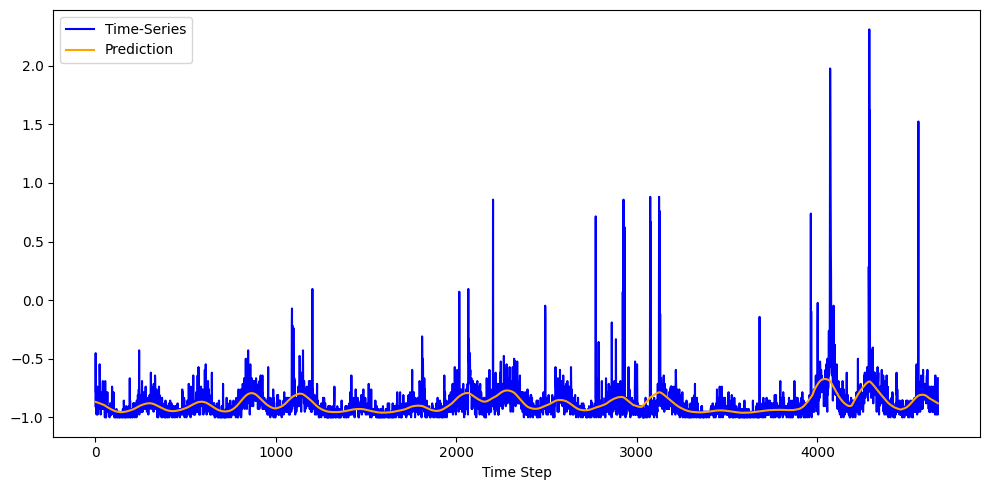

--------------
Twitter Signal 8
--------------
Epoch   5 | Train Loss: 0.003895 | Val Loss: 0.003301
Epoch  10 | Train Loss: 0.003701 | Val Loss: 0.003358
Epoch  15 | Train Loss: 0.003388 | Val Loss: 0.003167
Epoch  20 | Train Loss: 0.003380 | Val Loss: 0.003286
Epoch  25 | Train Loss: 0.003494 | Val Loss: 0.003223
Early stopping at epoch 28

Metrics
-------
Precision = 0.3333
Recall = 1.0000
F1 = 0.5000


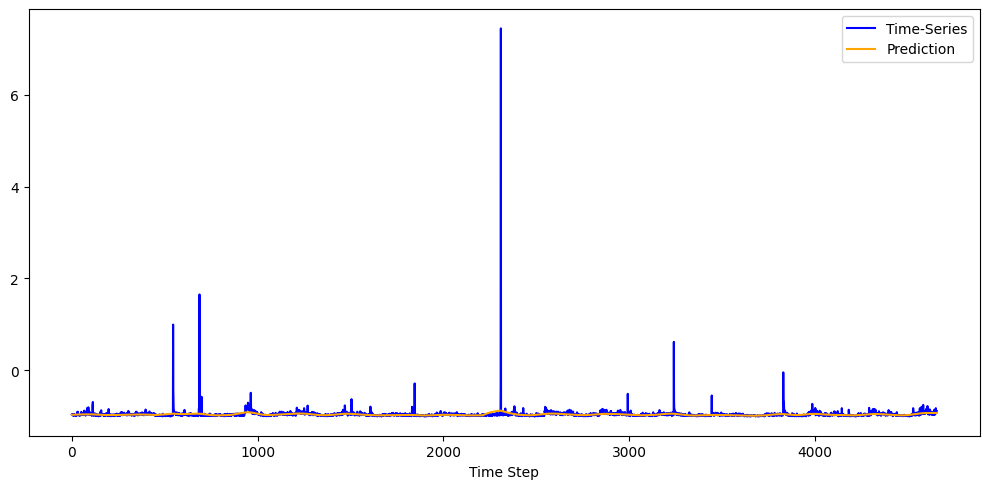

--------------
Twitter Signal 9
--------------
Epoch   5 | Train Loss: 0.005885 | Val Loss: 0.005487
Epoch  10 | Train Loss: 0.005133 | Val Loss: 0.005108
Epoch  15 | Train Loss: 0.005048 | Val Loss: 0.004884
Epoch  20 | Train Loss: 0.005021 | Val Loss: 0.004831
Epoch  25 | Train Loss: 0.005008 | Val Loss: 0.004839
Early stopping at epoch 26

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


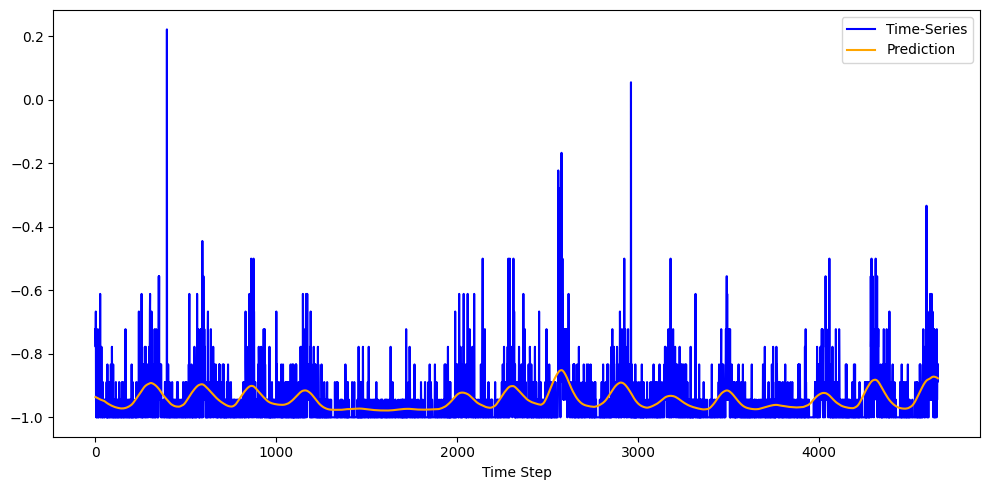

--------------
Twitter Signal 10
--------------
Epoch   5 | Train Loss: 0.042019 | Val Loss: 0.029729
Epoch  10 | Train Loss: 0.039790 | Val Loss: 0.028971
Epoch  15 | Train Loss: 0.039391 | Val Loss: 0.028833
Epoch  20 | Train Loss: 0.039420 | Val Loss: 0.028855
Early stopping at epoch 22

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


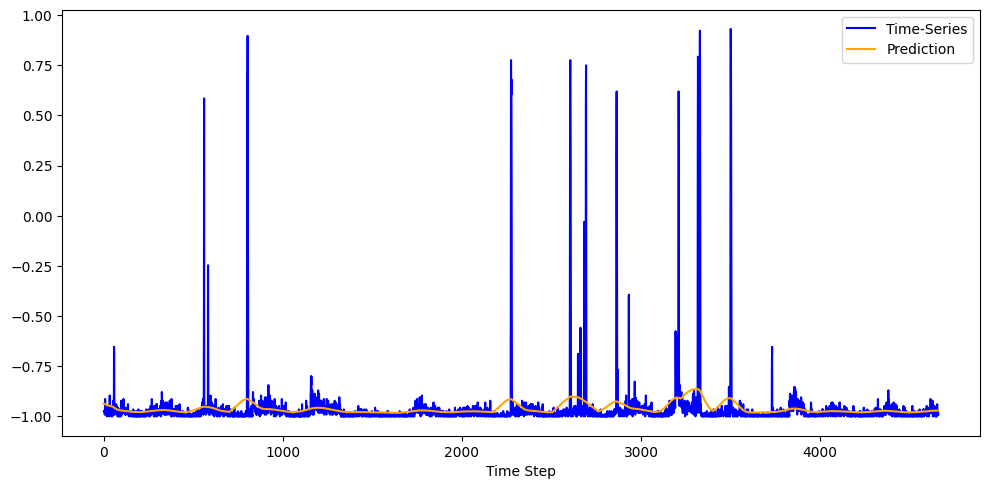

---------------
Twitter Metrics
---------------
Precision: 0.128
Recall: 0.400
F1: 0.190



In [21]:
total_precision, total_recall, total_f1 = 0, 0, 0

for i, twitter_signal in enumerate(twitter_signals):
    X = twitter_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = twitter_signal['is_anomaly'].to_numpy()

    print("--------------")
    print(f"Twitter Signal {i + 1}")
    print("--------------")
    
    precision, recall, f1, = run_pipeline(X, y, **NAB_HYPERPARAMS)
    total_precision += precision
    total_recall += recall
    total_f1 += f1

total_precision /= len(twitter_signals)
total_recall /= len(twitter_signals)
total_f1 /= len(twitter_signals)

print("---------------")
print("Twitter Metrics")
print("---------------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

## **Yahoo S5**

In [22]:
A1_FOLDER = "https://raw.githubusercontent.com/harris0704/nbaData16-17/refs/heads/master/Yahoo_S5_Data/A1Benchmark/"
A1_FILE_NAME = "real_"
A1_N_FILES = 67

A2_FOLDER = "https://raw.githubusercontent.com/harris0704/nbaData16-17/refs/heads/master/Yahoo_S5_Data/A2Benchmark/"
A2_FILE_NAME = "synthetic_"
A2_N_FILES = 100

A3_FOLDER = "https://raw.githubusercontent.com/harris0704/nbaData16-17/refs/heads/master/Yahoo_S5_Data/A3Benchmark/"
A3_FILE_NAME = "A3Benchmark-TS"
A3_N_FILES = 100

A4_FOLDER = "https://raw.githubusercontent.com/harris0704/nbaData16-17/refs/heads/master/Yahoo_S5_Data/A4Benchmark/"
A4_FILE_NAME = "A4Benchmark-TS"
A4_N_FILES = 100

In [23]:
YAHOO_HYPERPARAMS = {
    "train_ratio": 0.6,
    "val_ratio": 0.1,
    "lr": 1e-4,
    "epochs": 200,
    "patience": 15,
    "device": device,
    "anomaly_type": "contextual",
    "verbose": False,
}

In [24]:
def yahoo_download_subdataset(folder: str, file_name: str, n_files: int) -> t.List[pd.DataFrame]:
    yahoo_signals = []
    yahoo_points = 0
    yahoo_anomalies = 0

    for i in range(1, n_files + 1):
        # name of the .csv in the repository
        yahoo_fn = f"{file_name}{i}.csv"
        # url to the raw .csv file in the repository
        yahoo_url = f"{folder}{yahoo_fn}"
        yahoo_df = pd.read_csv(yahoo_url)
        yahoo_df = yahoo_df.rename(columns={"anomaly": "is_anomaly", "timestamps": "timestamp"})
        
        # count the number of points and the number of anomaly points
        yahoo_points += len(yahoo_df)
        yahoo_anomalies += (yahoo_df["is_anomaly"] == 1).sum()
        yahoo_signals.append(yahoo_df)

        if i % 10 == 0:
            print(f"Downloaded {i} .csv files.")

    print()
    print("Finished downloading!")
    print("---------------------")
    print(f"A1 Total Signals: {A1_N_FILES}")
    print(F"A1 Total Points: {yahoo_points}")
    print(f"A1 Total Anomaly Points: {yahoo_anomalies}")
    print(f"A1 Anomaly Rate: {(yahoo_anomalies / yahoo_points) * 100:.2f}%")

    return yahoo_signals

### **A1**

In [25]:
a1_signals = yahoo_download_subdataset(folder=A1_FOLDER, file_name=A1_FILE_NAME, n_files=A1_N_FILES)

Downloaded 10 .csv files.
Downloaded 20 .csv files.
Downloaded 30 .csv files.
Downloaded 40 .csv files.
Downloaded 50 .csv files.
Downloaded 60 .csv files.

Finished downloading!
---------------------
A1 Total Signals: 67
A1 Total Points: 94866
A1 Total Anomaly Points: 1669
A1 Anomaly Rate: 1.76%


In [26]:
total_precision, total_recall, total_f1, total_evaluated = 0, 0, 0, 0

for i, a1_signal in enumerate(a1_signals):
    X = a1_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = a1_signal['is_anomaly'].to_numpy()

    if (i + 1) % 5 == 0:
        print(f"A1 Signal {i + 1}...")

    try:
        precision, recall, f1, = run_pipeline(X, y, **YAHOO_HYPERPARAMS)
        total_precision += precision
        total_recall += recall
        total_f1 += f1
        total_evaluated += 1
    except:
        continue

total_precision /= total_evaluated
total_recall /= total_evaluated
total_f1 /= total_evaluated

print("----------")
print("A1 Metrics")
print("----------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

A1 Signal 5...
A1 Signal 10...
A1 Signal 15...
A1 Signal 20...
A1 Signal 25...
A1 Signal 30...
A1 Signal 35...
A1 Signal 40...
A1 Signal 45...
A1 Signal 50...
A1 Signal 55...
A1 Signal 60...
A1 Signal 65...
----------
A1 Metrics
----------
Precision: 0.657
Recall: 0.657
F1: 0.657



### **A2**

In [27]:
A2_HYPERPARAMS = YAHOO_HYPERPARAMS.copy()
A2_HYPERPARAMS["train_ratio"] = 0.4

In [28]:
a2_signals = yahoo_download_subdataset(folder=A2_FOLDER, file_name=A2_FILE_NAME, n_files=A2_N_FILES)

Downloaded 10 .csv files.
Downloaded 20 .csv files.
Downloaded 30 .csv files.
Downloaded 40 .csv files.
Downloaded 50 .csv files.
Downloaded 60 .csv files.
Downloaded 70 .csv files.
Downloaded 80 .csv files.
Downloaded 90 .csv files.
Downloaded 100 .csv files.

Finished downloading!
---------------------
A1 Total Signals: 67
A1 Total Points: 142100
A1 Total Anomaly Points: 466
A1 Anomaly Rate: 0.33%


In [29]:
total_precision, total_recall, total_f1, total_evaluated = 0, 0, 0, 0

for i, a2_signal in enumerate(a2_signals):
    X = a2_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = a2_signal['is_anomaly'].to_numpy()
    
    if (i + 1) % 5 == 0:
        print(f"A2 Signal {i + 1}...")
    try:
        precision, recall, f1, = run_pipeline(X, y, **A2_HYPERPARAMS)
        total_precision += precision
        total_recall += recall
        total_f1 += f1
        total_evaluated += 1
    except:
        continue

total_precision /= total_evaluated
total_recall /= total_evaluated
total_f1 /= total_evaluated

print("----------")
print("A2 Metrics")
print("----------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

A2 Signal 5...
A2 Signal 10...
A2 Signal 15...
A2 Signal 20...
A2 Signal 25...
A2 Signal 30...
A2 Signal 35...
A2 Signal 40...
A2 Signal 45...
A2 Signal 50...
A2 Signal 55...
A2 Signal 60...
A2 Signal 65...
A2 Signal 70...
A2 Signal 75...
A2 Signal 80...
A2 Signal 85...
A2 Signal 90...
A2 Signal 95...
A2 Signal 100...
----------
A2 Metrics
----------
Precision: 0.467
Recall: 0.640
F1: 0.514



### **A3**

In [30]:
A3_HYPERPARAMS = YAHOO_HYPERPARAMS.copy()
A3_HYPERPARAMS["train_ratio"] = 0.4

In [31]:
a3_signals = yahoo_download_subdataset(folder=A3_FOLDER, file_name=A3_FILE_NAME, n_files=A3_N_FILES)

Downloaded 10 .csv files.
Downloaded 20 .csv files.
Downloaded 30 .csv files.
Downloaded 40 .csv files.
Downloaded 50 .csv files.
Downloaded 60 .csv files.
Downloaded 70 .csv files.
Downloaded 80 .csv files.
Downloaded 90 .csv files.
Downloaded 100 .csv files.

Finished downloading!
---------------------
A1 Total Signals: 67
A1 Total Points: 168000
A1 Total Anomaly Points: 943
A1 Anomaly Rate: 0.56%


In [32]:
total_precision, total_recall, total_f1, total_evaluated = 0, 0, 0, 0

for i, a3_signal in enumerate(a3_signals):
    X = a3_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = a3_signal['is_anomaly'].to_numpy()
    
    if (i + 1) % 5 == 0:
        print(f"A3 Signal {i + 1}...")

    try:
        precision, recall, f1, = run_pipeline(X, y, **A3_HYPERPARAMS)
        total_precision += precision
        total_recall += recall
        total_f1 += f1
        total_evaluated += 1
    except:
        continue

total_precision /= total_evaluated
total_recall /= total_evaluated
total_f1 /= total_evaluated

print("----------")
print("A3 Metrics")
print("----------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

A3 Signal 5...
A3 Signal 10...
A3 Signal 15...
A3 Signal 20...
A3 Signal 25...
A3 Signal 30...
A3 Signal 35...
A3 Signal 40...
A3 Signal 45...
A3 Signal 50...
A3 Signal 55...
A3 Signal 60...
A3 Signal 65...
A3 Signal 70...
A3 Signal 75...
A3 Signal 80...
A3 Signal 85...
A3 Signal 90...
A3 Signal 95...
A3 Signal 100...
----------
A3 Metrics
----------
Precision: 0.370
Recall: 0.370
F1: 0.370



### **A4**

In [33]:
A4_HYPERPARAMS = YAHOO_HYPERPARAMS.copy()
A4_HYPERPARAMS["train_ratio"] = 0.4

In [34]:
a4_signals = yahoo_download_subdataset(folder=A4_FOLDER, file_name=A4_FILE_NAME, n_files=A4_N_FILES)

Downloaded 10 .csv files.
Downloaded 20 .csv files.
Downloaded 30 .csv files.
Downloaded 40 .csv files.
Downloaded 50 .csv files.
Downloaded 60 .csv files.
Downloaded 70 .csv files.
Downloaded 80 .csv files.
Downloaded 90 .csv files.
Downloaded 100 .csv files.

Finished downloading!
---------------------
A1 Total Signals: 67
A1 Total Points: 168000
A1 Total Anomaly Points: 837
A1 Anomaly Rate: 0.50%


In [35]:
total_precision, total_recall, total_f1, total_evaluated = 0, 0, 0, 0

for i, a4_signal in enumerate(a4_signals):
    X = a4_signal['value'].to_numpy()
    # expand from shape (T, ) to (T, 1)  
    X = np.expand_dims(X, axis=1)
    y = a4_signal['is_anomaly'].to_numpy()
    
    if (i + 1) % 5 == 0:
        print(f"A4 Signal {i + 1}...")

    try:
        precision, recall, f1, = run_pipeline(X, y, **A4_HYPERPARAMS)
        total_precision += precision
        total_recall += recall
        total_f1 += f1
        total_evaluated += 1
    except:
        continue

total_precision /= total_evaluated
total_recall /= total_evaluated
total_f1 /= total_evaluated

print("----------")
print("A4 Metrics")
print("----------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

A4 Signal 5...
A4 Signal 10...
A4 Signal 15...
A4 Signal 20...
A4 Signal 25...
A4 Signal 30...
A4 Signal 35...
A4 Signal 40...
A4 Signal 45...
A4 Signal 50...
A4 Signal 55...
A4 Signal 60...
A4 Signal 65...
A4 Signal 70...
A4 Signal 75...
A4 Signal 80...
A4 Signal 85...
A4 Signal 90...
A4 Signal 95...
A4 Signal 100...
----------
A4 Metrics
----------
Precision: 0.200
Recall: 0.200
F1: 0.200



## **NASA**

In [40]:
NASA_SPLIT_REPO = "https://raw.githubusercontent.com/ML4ITS/mtad-gat-pytorch/refs/heads/main/datasets/data/"
NASA_LABELS_FILE = "labeled_anomalies.csv"
NASA_MSL_SPLIT = "msl_train_md.csv"
NASA_SMAP_SPLIT = "smap_train_md.csv"

In [41]:
NASA_HYPERPARAMS = {
    "train_ratio": 0.9,
    "val_ratio": 0.1,
    "lr": 1e-4,
    "epochs": 200,
    "patience": 15,
    "device": device,
    "anomaly_type": "contextual",
    "verbose": False,
}

In [42]:
nasa_dataset_path = kagglehub.dataset_download("patrickfleith/nasa-anomaly-detection-dataset-smap-msl")
# path to the training samples from the Kaggle dataset
nasa_train_path = os.path.join(nasa_dataset_path, "data", "data", "train")
# path to the testing samples from the Kaggle dataset
nasa_test_path = os.path.join(nasa_dataset_path, "data", "data", "test")

In [43]:
# download the NASA labels that correspond to the labels for test data
nasa_labels_url = f"{NASA_SPLIT_REPO}{NASA_LABELS_FILE}"
nasa_labels = pd.read_csv(nasa_labels_url)

### **MSL**

In [44]:
MSL_HYPERPARAMS = NASA_HYPERPARAMS.copy()
MSL_HYPERPARAMS["verbose"] = True

In [45]:
msl_split_url = f"{NASA_SPLIT_REPO}{NASA_MSL_SPLIT}"
msl_split = pd.read_csv(msl_split_url)

# extract the channel names corresponding to the MSL dataset
msl_channel_names = list(msl_split["chan_id"].values) 
# add the .npy file extensions to the MSL file names
msl_file_names = [f"{msl_file_name}.npy" for msl_file_name in msl_channel_names]
# sort them alphabetically
msl_file_names.sort()

In [46]:
msl_train: list[np.ndarray] = []
msl_test: list[np.ndarray] = []
msl_test_y: list[list] = []

for msl_file_name in msl_file_names:
    # load both the train and test time series for the same channel, concatenate
    # the time series and add them to the MSL dataset
    msl_train_ts = np.load(os.path.join(nasa_train_path, msl_file_name))
    msl_test_ts = np.load(os.path.join(nasa_test_path, msl_file_name))

    # extract the anomaly labels for the test time-series
    # -4 is needed to get rid of the file extension from the name
    row = nasa_labels[nasa_labels["chan_id"] == msl_file_name[:-4]]
    msl_test_interval_str = row["anomaly_sequences"].iloc[0]
    msl_test_interval = ast.literal_eval(msl_test_interval_str)
    msl_test_labels = intervals_to_points(msl_test_interval, len(msl_test_ts))

    msl_train.append(msl_train_ts)
    msl_test.append(msl_test_ts)

    msl_test_y.append(msl_test_labels)

Channel C-1 Signal...
Epoch   5 | Train Loss: 0.068135 | Val Loss: 0.035594
Epoch  10 | Train Loss: 0.060021 | Val Loss: 0.033102
Epoch  15 | Train Loss: 0.058923 | Val Loss: 0.035148
Epoch  20 | Train Loss: 0.049037 | Val Loss: 0.025549
Epoch  25 | Train Loss: 0.045226 | Val Loss: 0.023846
Epoch  30 | Train Loss: 0.044004 | Val Loss: 0.024234
Epoch  35 | Train Loss: 0.043968 | Val Loss: 0.024720
Epoch  40 | Train Loss: 0.044073 | Val Loss: 0.023999
Early stopping at epoch 40

Metrics
-------
Precision = 0.2000
Recall = 0.5000
F1 = 0.2857


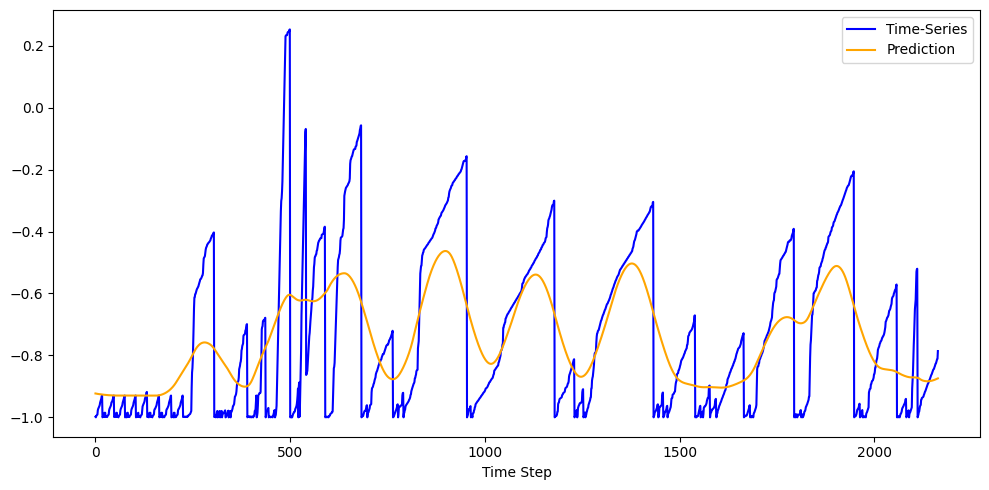

Channel C-2 Signal...
Epoch   5 | Train Loss: 0.394173 | Val Loss: 0.313580
Epoch  10 | Train Loss: 0.015915 | Val Loss: 0.016998
Epoch  15 | Train Loss: 0.011723 | Val Loss: 0.011301
Epoch  20 | Train Loss: 0.007911 | Val Loss: 0.007462
Epoch  25 | Train Loss: 0.003643 | Val Loss: 0.003154
Epoch  30 | Train Loss: 0.000212 | Val Loss: 0.000092
Epoch  35 | Train Loss: 0.000022 | Val Loss: 0.000020
Epoch  40 | Train Loss: 0.000016 | Val Loss: 0.000015
Epoch  45 | Train Loss: 0.000013 | Val Loss: 0.000012
Early stopping at epoch 46

Metrics
-------
Precision = 0.1429
Recall = 0.5000
F1 = 0.2222


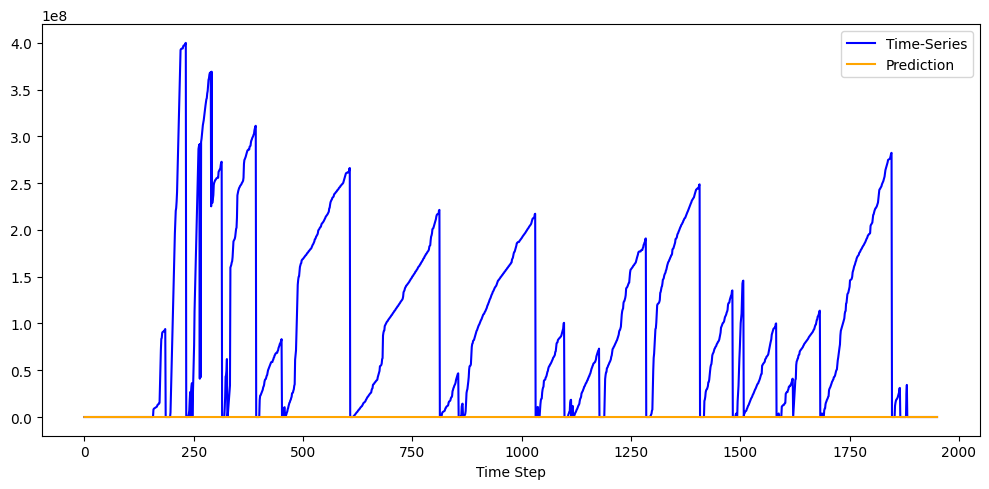

Channel D-14 Signal...
Epoch   5 | Train Loss: 0.000816 | Val Loss: 0.000168
Epoch  10 | Train Loss: 0.000027 | Val Loss: 0.000020
Epoch  15 | Train Loss: 0.000002 | Val Loss: 0.000002
Epoch  20 | Train Loss: 0.000001 | Val Loss: 0.000001
Early stopping at epoch 20

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


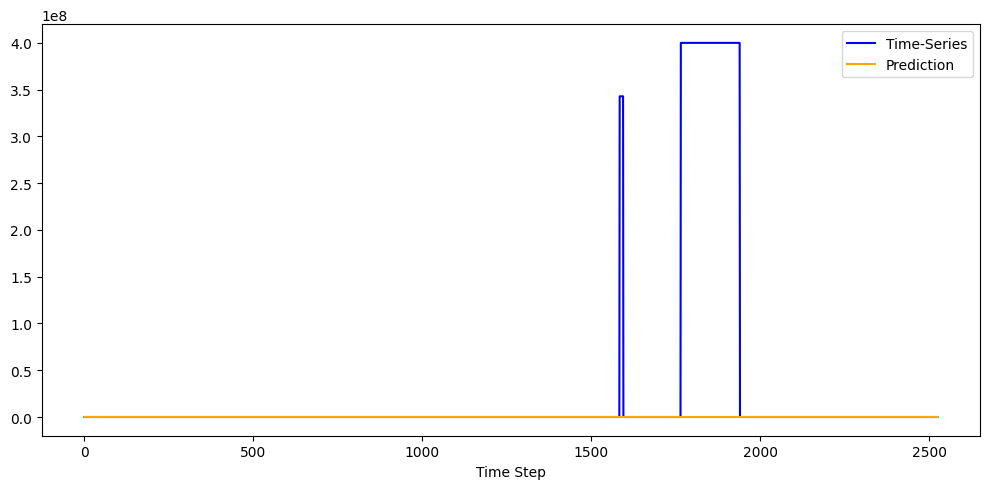

Channel D-15 Signal...
Epoch   5 | Train Loss: 0.365063 | Val Loss: 0.263595
Epoch  10 | Train Loss: 0.362625 | Val Loss: 0.260791
Epoch  15 | Train Loss: 0.360757 | Val Loss: 0.262616
Epoch  20 | Train Loss: 0.346918 | Val Loss: 0.260299
Epoch  25 | Train Loss: 0.345492 | Val Loss: 0.260270
Epoch  30 | Train Loss: 0.329268 | Val Loss: 0.265193
Epoch  35 | Train Loss: 0.317156 | Val Loss: 0.246171
Epoch  40 | Train Loss: 0.312990 | Val Loss: 0.231528
Epoch  45 | Train Loss: 0.310346 | Val Loss: 0.232642
Epoch  50 | Train Loss: 0.308331 | Val Loss: 0.227605
Epoch  55 | Train Loss: 0.307177 | Val Loss: 0.225305
Epoch  60 | Train Loss: 0.305202 | Val Loss: 0.223818
Epoch  65 | Train Loss: 0.304688 | Val Loss: 0.225426
Epoch  70 | Train Loss: 0.302404 | Val Loss: 0.229632
Epoch  75 | Train Loss: 0.301360 | Val Loss: 0.225764
Early stopping at epoch 75

Metrics
-------
Precision = 0.2500
Recall = 1.0000
F1 = 0.4000


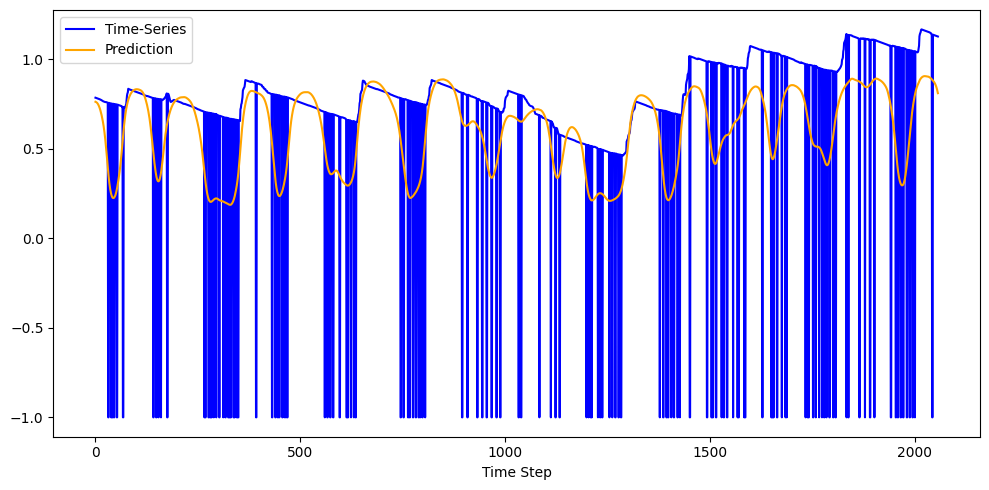

Channel D-16 Signal...
Epoch   5 | Train Loss: 0.531757 | Val Loss: 0.020664
Epoch  10 | Train Loss: 0.351213 | Val Loss: 0.002859
Epoch  15 | Train Loss: 0.348258 | Val Loss: 0.000644
Epoch  20 | Train Loss: 0.345655 | Val Loss: 0.000143
Epoch  25 | Train Loss: 0.344889 | Val Loss: 0.000321
Epoch  30 | Train Loss: 0.345160 | Val Loss: 0.000666
Early stopping at epoch 31

Metrics
-------
Precision = 0.2500
Recall = 1.0000
F1 = 0.4000


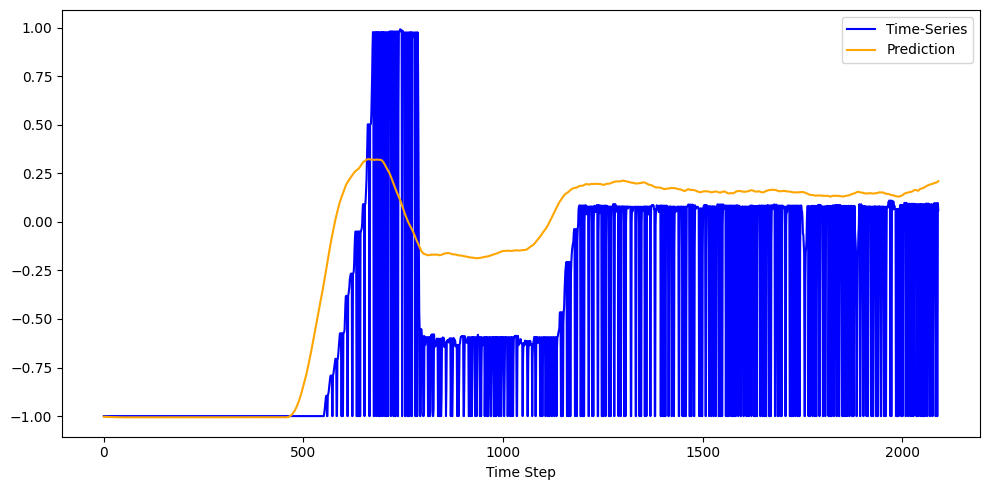

Channel F-4 Signal...
Epoch   5 | Train Loss: 0.203801 | Val Loss: 0.102838
Epoch  10 | Train Loss: 0.156942 | Val Loss: 0.039395
Epoch  15 | Train Loss: 0.140576 | Val Loss: 0.031304
Epoch  20 | Train Loss: 0.139317 | Val Loss: 0.033211
Epoch  25 | Train Loss: 0.138180 | Val Loss: 0.028462
Epoch  30 | Train Loss: 0.137718 | Val Loss: 0.028105
Epoch  35 | Train Loss: 0.134057 | Val Loss: 0.028748
Early stopping at epoch 39

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


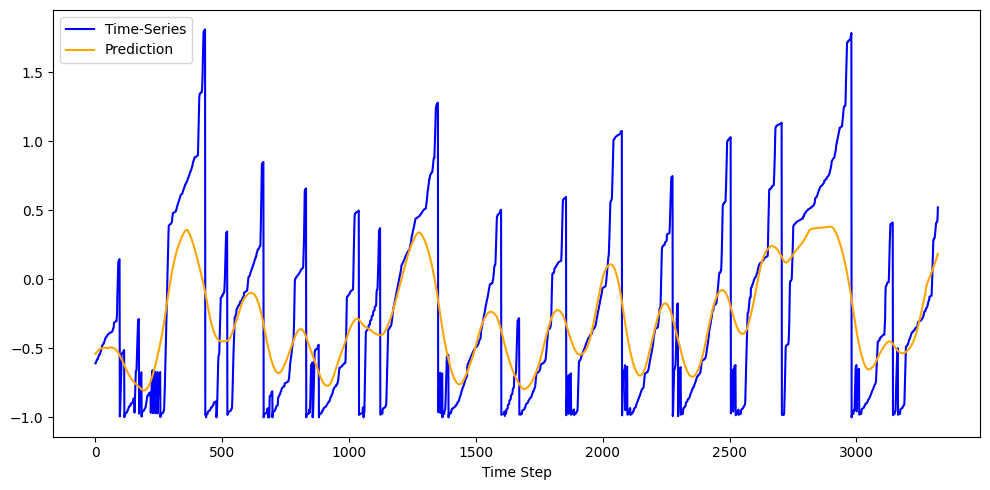

Channel F-5 Signal...
Epoch   5 | Train Loss: 0.114391 | Val Loss: 0.007417
Epoch  10 | Train Loss: 0.099553 | Val Loss: 0.004675
Epoch  15 | Train Loss: 0.074958 | Val Loss: 0.005693
Epoch  20 | Train Loss: 0.062236 | Val Loss: 0.004580
Epoch  25 | Train Loss: 0.061233 | Val Loss: 0.004308
Epoch  30 | Train Loss: 0.060467 | Val Loss: 0.003986
Epoch  35 | Train Loss: 0.056611 | Val Loss: 0.004020
Early stopping at epoch 38

Metrics
-------
Precision = 0.2000
Recall = 1.0000
F1 = 0.3333


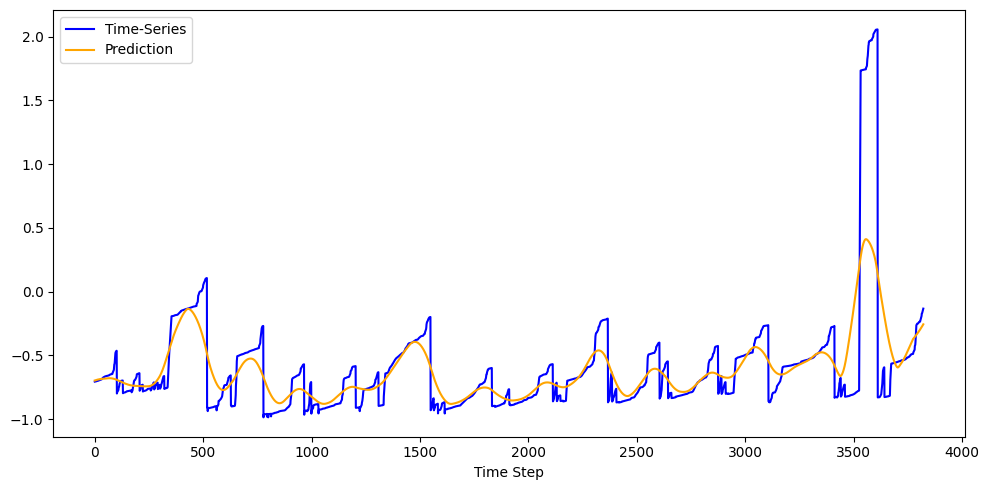

Channel F-7 Signal...
Epoch   5 | Train Loss: 0.369540 | Val Loss: 0.412039
Epoch  10 | Train Loss: 0.364112 | Val Loss: 0.410376
Epoch  15 | Train Loss: 0.353940 | Val Loss: 0.403017
Epoch  20 | Train Loss: 0.352475 | Val Loss: 0.399396
Epoch  25 | Train Loss: 0.352078 | Val Loss: 0.399508
Epoch  30 | Train Loss: 0.351382 | Val Loss: 0.398712
Epoch  35 | Train Loss: 0.351030 | Val Loss: 0.398509
Epoch  40 | Train Loss: 0.350801 | Val Loss: 0.398597
Epoch  45 | Train Loss: 0.351541 | Val Loss: 0.401186
Epoch  50 | Train Loss: 0.345056 | Val Loss: 0.390393
Epoch  55 | Train Loss: 0.341971 | Val Loss: 0.388925
Epoch  60 | Train Loss: 0.340445 | Val Loss: 0.389257
Epoch  65 | Train Loss: 0.338952 | Val Loss: 0.389885
Early stopping at epoch 69

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


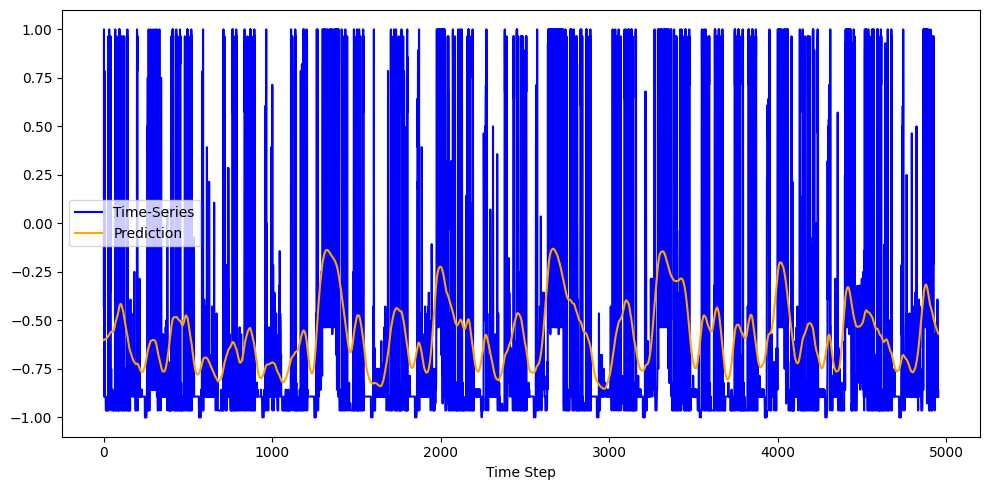

Channel F-8 Signal...
Epoch   5 | Train Loss: 0.204637 | Val Loss: 0.345657
Epoch  10 | Train Loss: 0.201852 | Val Loss: 0.344005
Epoch  15 | Train Loss: 0.194969 | Val Loss: 0.340543
Epoch  20 | Train Loss: 0.194122 | Val Loss: 0.340300
Epoch  25 | Train Loss: 0.193704 | Val Loss: 0.340118
Epoch  30 | Train Loss: 0.194356 | Val Loss: 0.340354
Epoch  35 | Train Loss: 0.193950 | Val Loss: 0.340031
Epoch  40 | Train Loss: 0.193351 | Val Loss: 0.340133
Early stopping at epoch 42

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


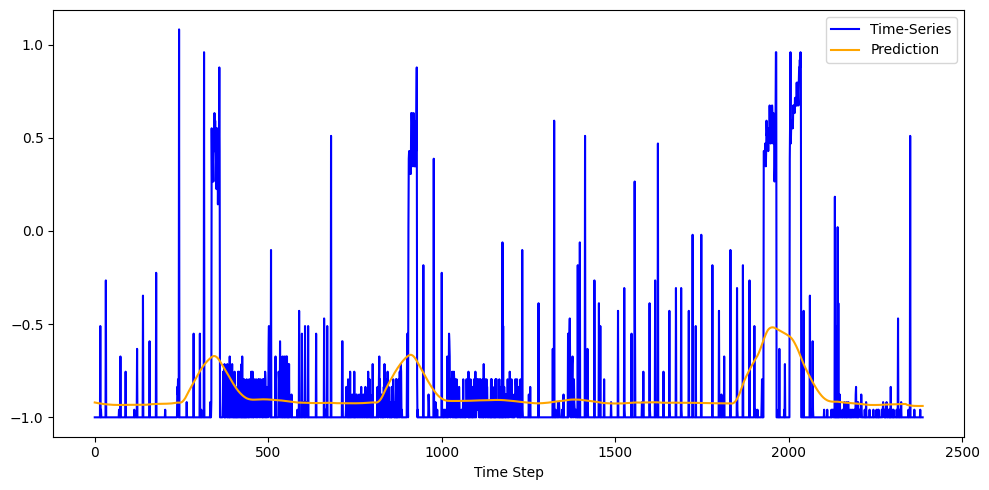

Channel M-1 Signal...
Epoch   5 | Train Loss: 0.142496 | Val Loss: 0.222802
Epoch  10 | Train Loss: 0.116984 | Val Loss: 0.187203
Epoch  15 | Train Loss: 0.115544 | Val Loss: 0.184100
Epoch  20 | Train Loss: 0.115317 | Val Loss: 0.183752
Epoch  25 | Train Loss: 0.114487 | Val Loss: 0.183192
Epoch  30 | Train Loss: 0.114987 | Val Loss: 0.182151
Epoch  35 | Train Loss: 0.114156 | Val Loss: 0.181929
Epoch  40 | Train Loss: 0.113489 | Val Loss: 0.182264
Epoch  45 | Train Loss: 0.109750 | Val Loss: 0.201105
Epoch  50 | Train Loss: 0.062605 | Val Loss: 0.107285
Epoch  55 | Train Loss: 0.056427 | Val Loss: 0.101132
Epoch  60 | Train Loss: 0.053027 | Val Loss: 0.088484
Epoch  65 | Train Loss: 0.050831 | Val Loss: 0.080571
Epoch  70 | Train Loss: 0.048844 | Val Loss: 0.076143
Epoch  75 | Train Loss: 0.046863 | Val Loss: 0.072844
Epoch  80 | Train Loss: 0.045596 | Val Loss: 0.069561
Epoch  85 | Train Loss: 0.037625 | Val Loss: 0.062629
Epoch  90 | Train Loss: 0.034221 | Val Loss: 0.069657
Epoch 

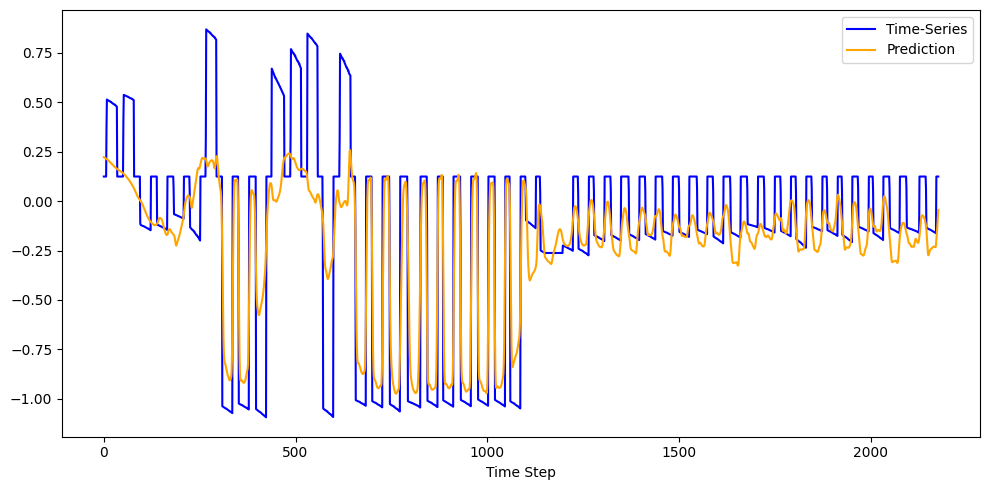

Channel M-2 Signal...
Epoch   5 | Train Loss: 0.062829 | Val Loss: 0.633897
Epoch  10 | Train Loss: 0.059847 | Val Loss: 0.598145
Epoch  15 | Train Loss: 0.058806 | Val Loss: 0.569738
Early stopping at epoch 16

Metrics
-------
Precision = 0.2500
Recall = 1.0000
F1 = 0.4000


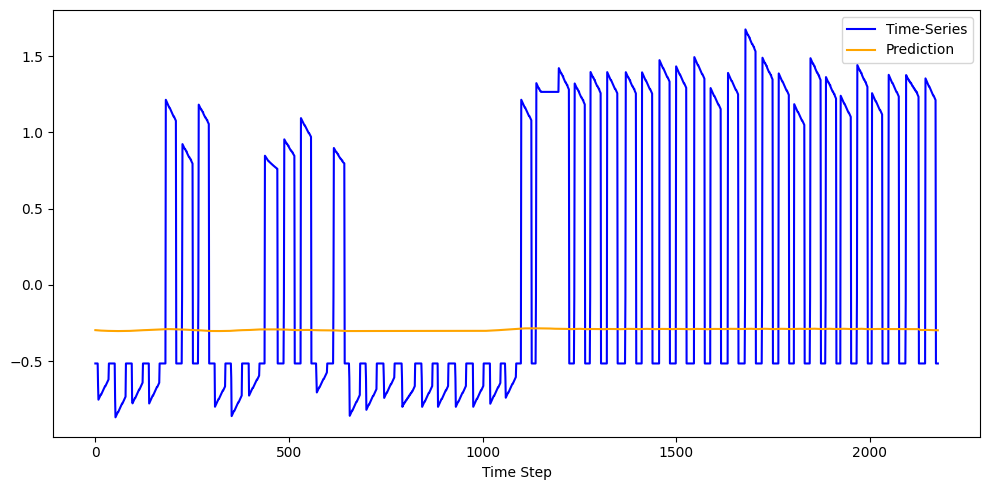

Channel M-3 Signal...
Epoch   5 | Train Loss: 0.333048 | Val Loss: 0.345169
Epoch  10 | Train Loss: 0.287770 | Val Loss: 0.357576
Epoch  15 | Train Loss: 0.205889 | Val Loss: 0.297539
Epoch  20 | Train Loss: 0.188246 | Val Loss: 0.267166
Epoch  25 | Train Loss: 0.191844 | Val Loss: 0.273637
Epoch  30 | Train Loss: 0.143884 | Val Loss: 0.309175
Epoch  35 | Train Loss: 0.155259 | Val Loss: 0.238642
Epoch  40 | Train Loss: 0.126910 | Val Loss: 0.235850
Early stopping at epoch 42

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


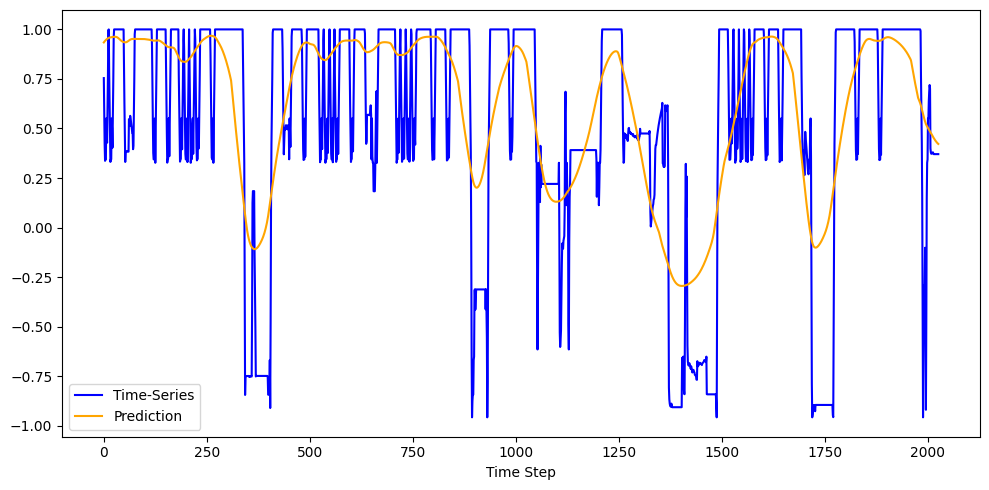

Channel M-4 Signal...
Epoch   5 | Train Loss: 0.273192 | Val Loss: 0.244734
Epoch  10 | Train Loss: 0.216098 | Val Loss: 0.224047
Epoch  15 | Train Loss: 0.192515 | Val Loss: 0.210541
Epoch  20 | Train Loss: 0.177852 | Val Loss: 0.200564
Epoch  25 | Train Loss: 0.173900 | Val Loss: 0.200892
Epoch  30 | Train Loss: 0.171711 | Val Loss: 0.201339
Epoch  35 | Train Loss: 0.171165 | Val Loss: 0.203783
Early stopping at epoch 36

Metrics
-------
Precision = 0.3333
Recall = 1.0000
F1 = 0.5000


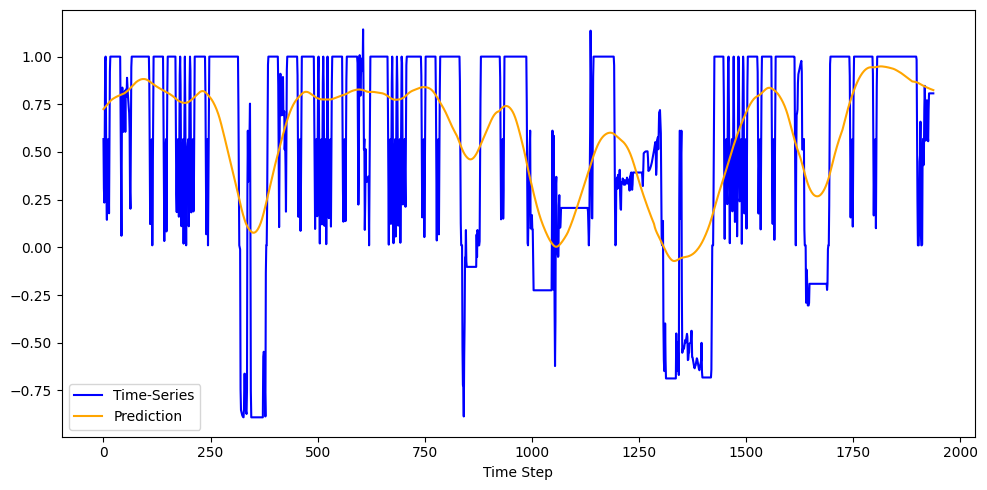

Channel M-5 Signal...
Epoch   5 | Train Loss: 0.343740 | Val Loss: 0.648005
Epoch  10 | Train Loss: 0.278747 | Val Loss: 0.512346
Epoch  15 | Train Loss: 0.263363 | Val Loss: 0.482543
Epoch  20 | Train Loss: 0.259516 | Val Loss: 0.473143
Epoch  25 | Train Loss: 0.254444 | Val Loss: 0.440320
Epoch  30 | Train Loss: 0.257639 | Val Loss: 0.418230
Epoch  35 | Train Loss: 0.253134 | Val Loss: 0.399934
Epoch  40 | Train Loss: 0.241748 | Val Loss: 0.344071
Epoch  45 | Train Loss: 0.240814 | Val Loss: 0.330847
Epoch  50 | Train Loss: 0.224839 | Val Loss: 0.336751
Epoch  55 | Train Loss: 0.219661 | Val Loss: 0.335037
Epoch  60 | Train Loss: 0.231968 | Val Loss: 0.334690
Early stopping at epoch 60

Metrics
-------
Precision = 0.2000
Recall = 1.0000
F1 = 0.3333


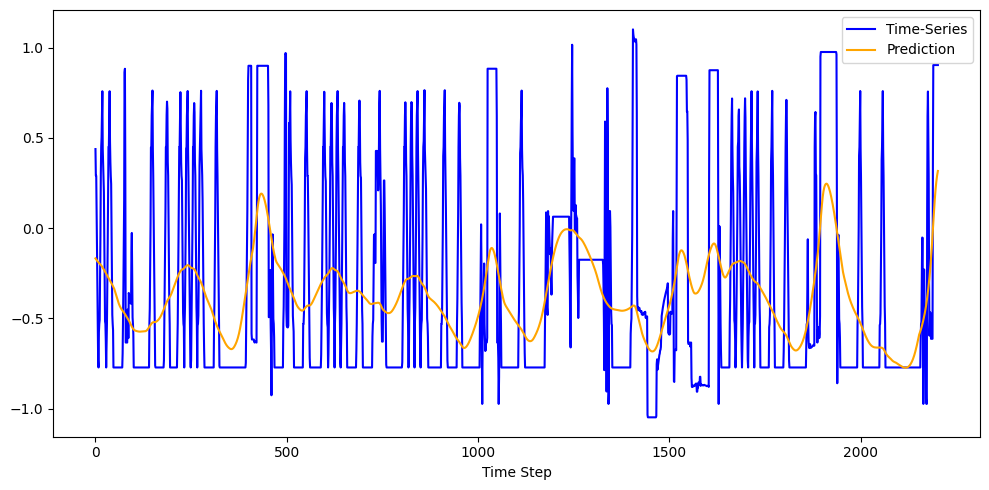

Channel M-6 Signal...
Epoch   5 | Train Loss: 0.021652 | Val Loss: 0.018702
Epoch  10 | Train Loss: 0.008372 | Val Loss: 0.007083
Epoch  15 | Train Loss: 0.000196 | Val Loss: 0.000161
Epoch  20 | Train Loss: 0.000035 | Val Loss: 0.000029
Epoch  25 | Train Loss: 0.000007 | Val Loss: 0.000006
Early stopping at epoch 29

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


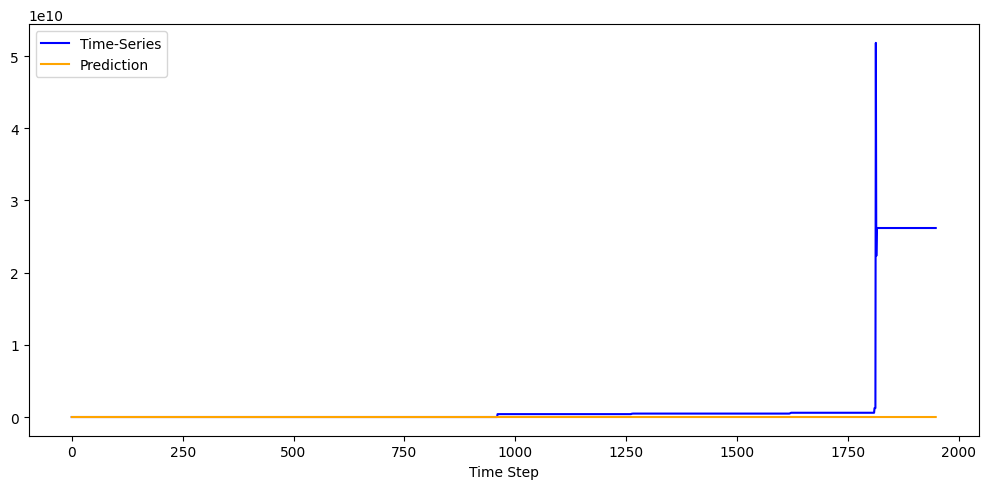

Channel M-7 Signal...
Epoch   5 | Train Loss: 0.043741 | Val Loss: 0.010358
Epoch  10 | Train Loss: 0.035580 | Val Loss: 0.002253
Epoch  15 | Train Loss: 0.033175 | Val Loss: 0.000465
Epoch  20 | Train Loss: 0.032954 | Val Loss: 0.000532
Epoch  25 | Train Loss: 0.032727 | Val Loss: 0.000654
Early stopping at epoch 27

Metrics
-------
Precision = 0.3333
Recall = 1.0000
F1 = 0.5000


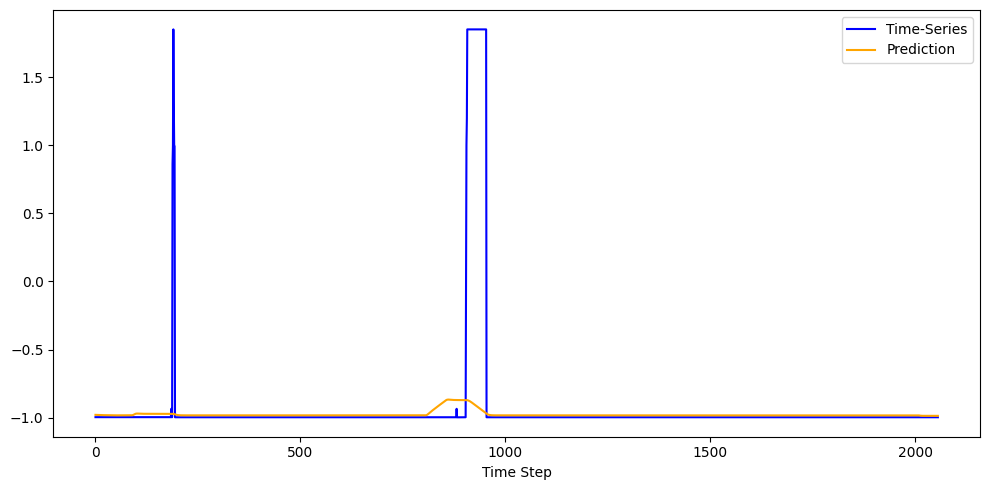

Channel P-10 Signal...
Epoch   5 | Train Loss: 0.026408 | Val Loss: 0.028287
Epoch  10 | Train Loss: 0.026286 | Val Loss: 0.028369
Epoch  15 | Train Loss: 0.025915 | Val Loss: 0.028151
Early stopping at epoch 16

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


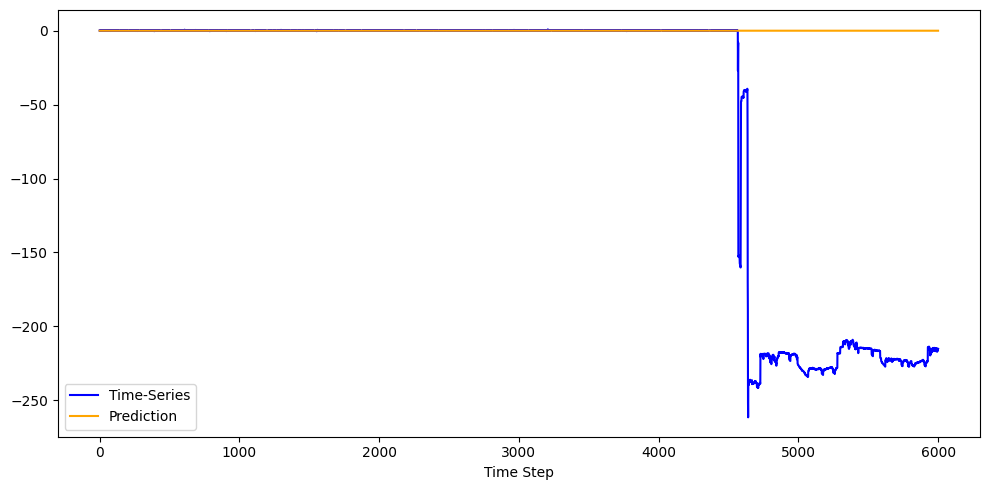

Channel P-11 Signal...
Epoch   5 | Train Loss: 0.106467 | Val Loss: 0.052106
Epoch  10 | Train Loss: 0.084319 | Val Loss: 0.048341
Epoch  15 | Train Loss: 0.082291 | Val Loss: 0.047802
Epoch  20 | Train Loss: 0.082294 | Val Loss: 0.047636
Epoch  25 | Train Loss: 0.081937 | Val Loss: 0.047779
Epoch  30 | Train Loss: 0.080223 | Val Loss: 0.047573
Epoch  35 | Train Loss: 0.062973 | Val Loss: 0.044596
Epoch  40 | Train Loss: 0.059723 | Val Loss: 0.044070
Epoch  45 | Train Loss: 0.056890 | Val Loss: 0.043977
Epoch  50 | Train Loss: 0.053861 | Val Loss: 0.041438
Epoch  55 | Train Loss: 0.050618 | Val Loss: 0.043237
Epoch  60 | Train Loss: 0.049326 | Val Loss: 0.043955
Epoch  65 | Train Loss: 0.047924 | Val Loss: 0.039818
Epoch  70 | Train Loss: 0.046823 | Val Loss: 0.039932
Epoch  75 | Train Loss: 0.046178 | Val Loss: 0.038340
Epoch  80 | Train Loss: 0.045407 | Val Loss: 0.038317
Epoch  85 | Train Loss: 0.045139 | Val Loss: 0.039358
Epoch  90 | Train Loss: 0.043671 | Val Loss: 0.036466
Epoch

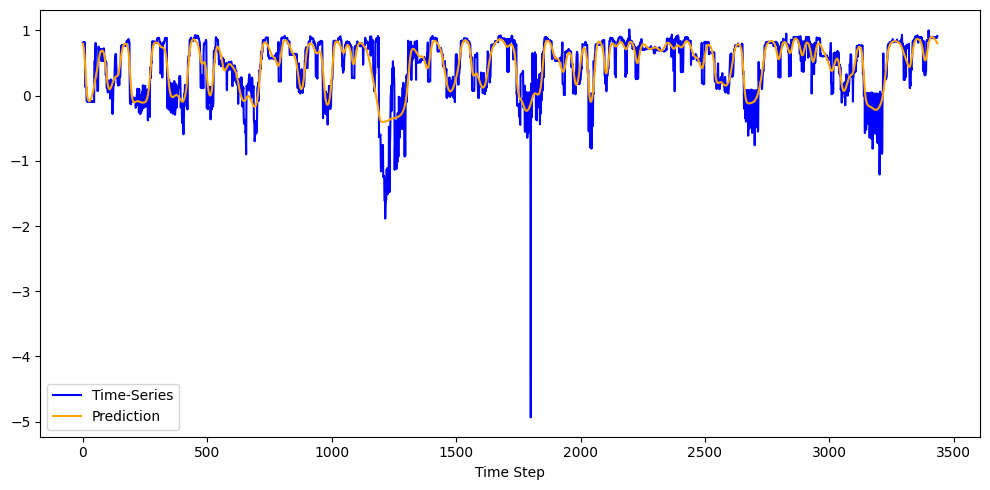

Channel P-14 Signal...
Epoch   5 | Train Loss: 0.026718 | Val Loss: 0.028131
Epoch  10 | Train Loss: 0.026695 | Val Loss: 0.028116
Epoch  15 | Train Loss: 0.026261 | Val Loss: 0.027962
Early stopping at epoch 16

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


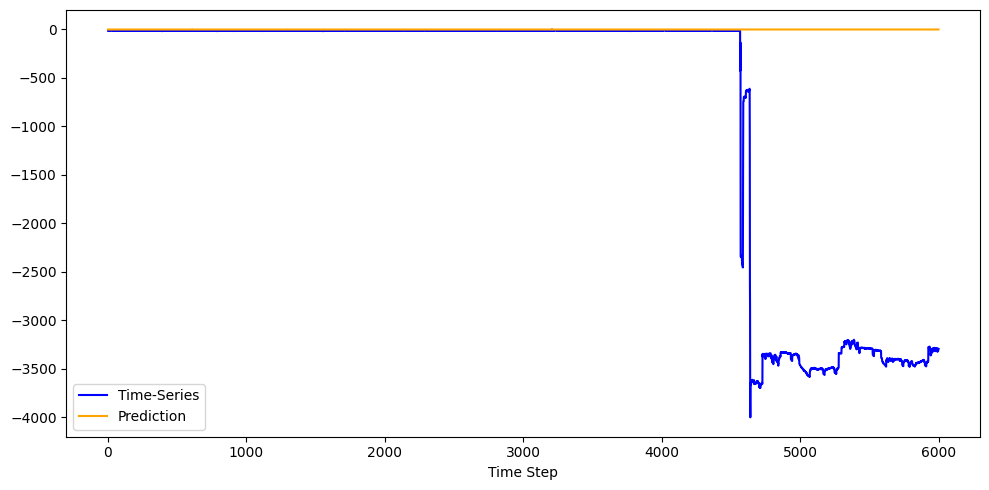

Channel P-15 Signal...
Epoch   5 | Train Loss: 0.027570 | Val Loss: 0.011854
Epoch  10 | Train Loss: 0.021488 | Val Loss: 0.009774
Epoch  15 | Train Loss: 0.020470 | Val Loss: 0.009109
Epoch  20 | Train Loss: 0.020019 | Val Loss: 0.009055
Epoch  25 | Train Loss: 0.019558 | Val Loss: 0.011868
Epoch  30 | Train Loss: 0.017886 | Val Loss: 0.011537
Epoch  35 | Train Loss: 0.014690 | Val Loss: 0.009163
Epoch  40 | Train Loss: 0.012601 | Val Loss: 0.007318
Epoch  45 | Train Loss: 0.012033 | Val Loss: 0.006617
Epoch  50 | Train Loss: 0.009979 | Val Loss: 0.006513
Epoch  55 | Train Loss: 0.009814 | Val Loss: 0.006954
Epoch  60 | Train Loss: 0.009837 | Val Loss: 0.005763
Early stopping at epoch 63

Metrics
-------
Precision = 0.1429
Recall = 1.0000
F1 = 0.2500


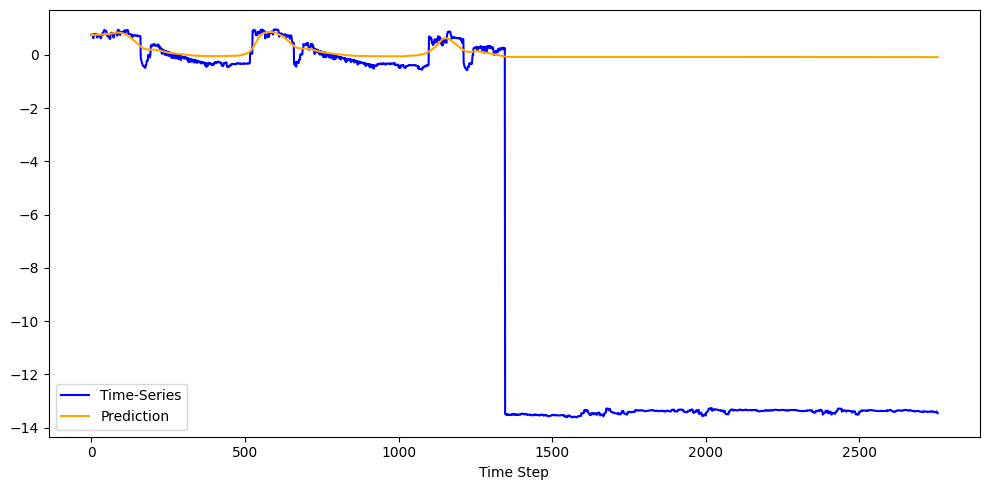

Channel S-2 Signal...
Epoch   5 | Train Loss: 0.101685 | Val Loss: 0.027486
Epoch  10 | Train Loss: 0.014911 | Val Loss: 0.014057
Epoch  15 | Train Loss: 0.007343 | Val Loss: 0.006428
Epoch  20 | Train Loss: 0.000193 | Val Loss: 0.000053
Epoch  25 | Train Loss: 0.000028 | Val Loss: 0.000026
Epoch  30 | Train Loss: 0.000015 | Val Loss: 0.000014
Epoch  35 | Train Loss: 0.000008 | Val Loss: 0.000008
Early stopping at epoch 35

Metrics
-------
Precision = 1.0000
Recall = 1.0000
F1 = 1.0000


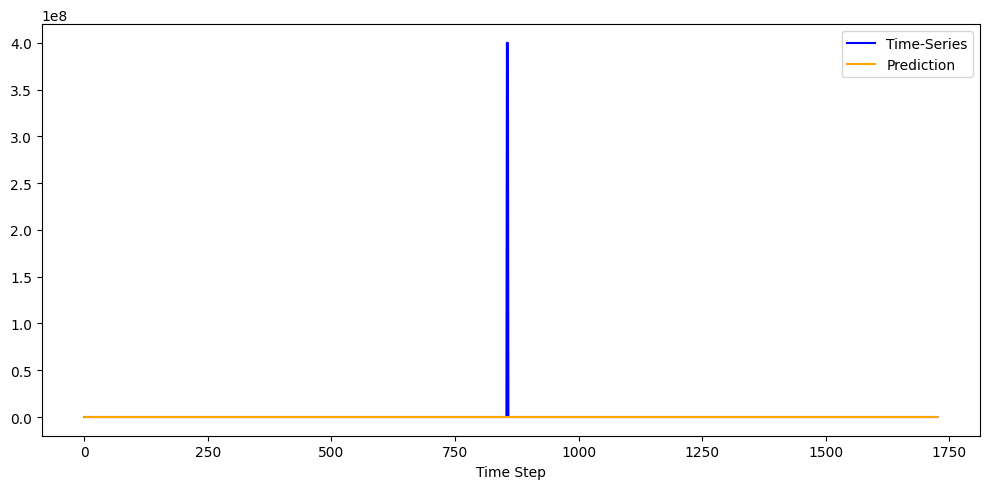

Channel T-12 Signal...
Epoch   5 | Train Loss: 0.210115 | Val Loss: 0.251585
Epoch  10 | Train Loss: 0.148471 | Val Loss: 0.037723
Epoch  15 | Train Loss: 0.125227 | Val Loss: 0.079993
Epoch  20 | Train Loss: 0.089985 | Val Loss: 0.072274
Epoch  25 | Train Loss: 0.084159 | Val Loss: 0.060002
Early stopping at epoch 25

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


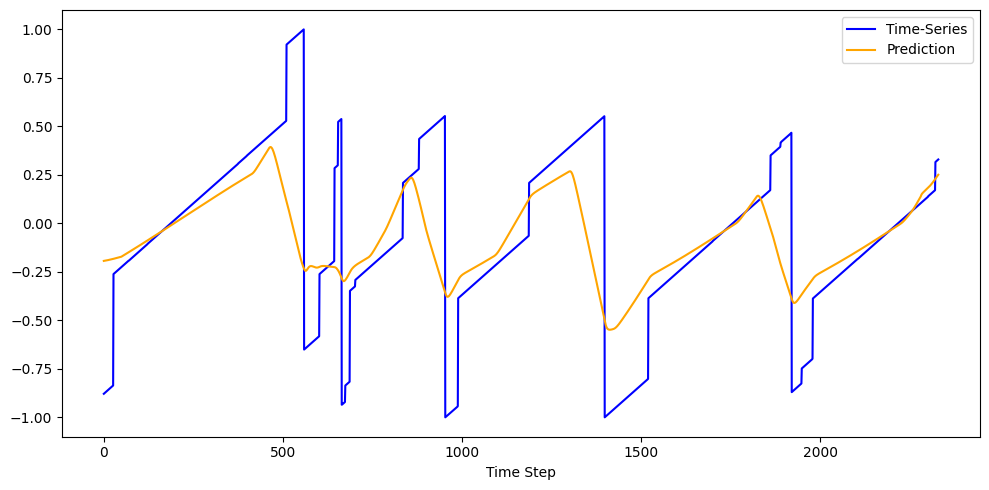

Channel T-13 Signal...
Epoch   5 | Train Loss: 0.271727 | Val Loss: 0.324922
Epoch  10 | Train Loss: 0.013660 | Val Loss: 0.034003
Epoch  15 | Train Loss: 0.011318 | Val Loss: 0.024785
Epoch  20 | Train Loss: 0.009460 | Val Loss: 0.015867
Epoch  25 | Train Loss: 0.008361 | Val Loss: 0.012288
Epoch  30 | Train Loss: 0.007816 | Val Loss: 0.011508
Epoch  35 | Train Loss: 0.007496 | Val Loss: 0.011473
Epoch  40 | Train Loss: 0.007378 | Val Loss: 0.011597
Early stopping at epoch 42

Metrics
-------
Precision = 0.0909
Recall = 0.5000
F1 = 0.1538


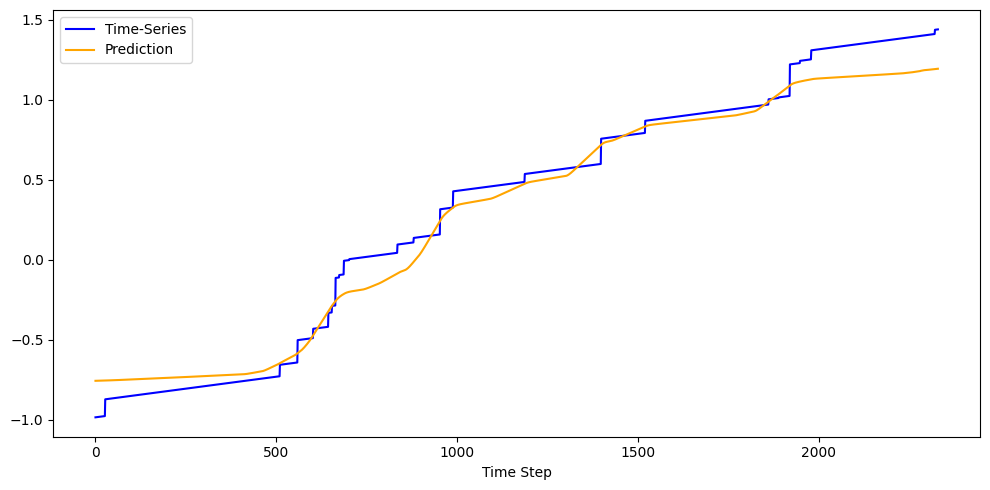

Channel T-4 Signal...
Epoch   5 | Train Loss: 0.980512 | Val Loss: 0.965580
Epoch  10 | Train Loss: 0.913050 | Val Loss: 0.954997
Epoch  15 | Train Loss: 0.908670 | Val Loss: 0.948296
Epoch  20 | Train Loss: 0.849917 | Val Loss: 0.877514
Epoch  25 | Train Loss: 0.828270 | Val Loss: 0.861286
Epoch  30 | Train Loss: 0.785959 | Val Loss: 0.801574
Epoch  35 | Train Loss: 0.758556 | Val Loss: 0.787115
Epoch  40 | Train Loss: 0.716847 | Val Loss: 0.640038
Epoch  45 | Train Loss: 0.671215 | Val Loss: 0.600436
Epoch  50 | Train Loss: 0.636133 | Val Loss: 0.541487
Epoch  55 | Train Loss: 0.603028 | Val Loss: 0.560427
Epoch  60 | Train Loss: 0.757329 | Val Loss: 0.905590
Epoch  65 | Train Loss: 0.689948 | Val Loss: 0.634009
Epoch  70 | Train Loss: 0.618064 | Val Loss: 0.600459
Early stopping at epoch 73

Metrics
-------
Precision = 0.2000
Recall = 1.0000
F1 = 0.3333


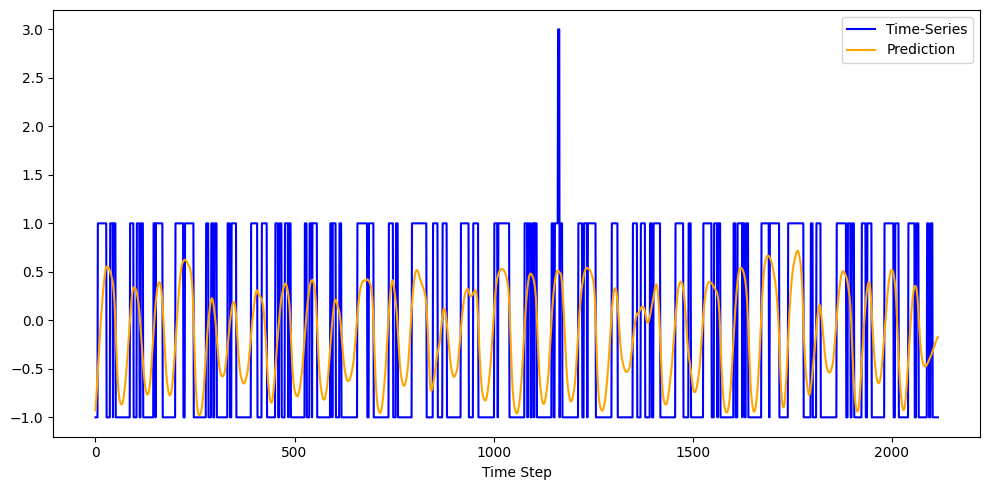

Channel T-5 Signal...
Epoch   5 | Train Loss: 0.013234 | Val Loss: 0.011584
Epoch  10 | Train Loss: 0.000010 | Val Loss: 0.000005
Epoch  15 | Train Loss: 0.000001 | Val Loss: 0.000001
Epoch  20 | Train Loss: 0.000000 | Val Loss: 0.000000
Early stopping at epoch 24

Metrics
-------
Precision = 0.3333
Recall = 1.0000
F1 = 0.5000


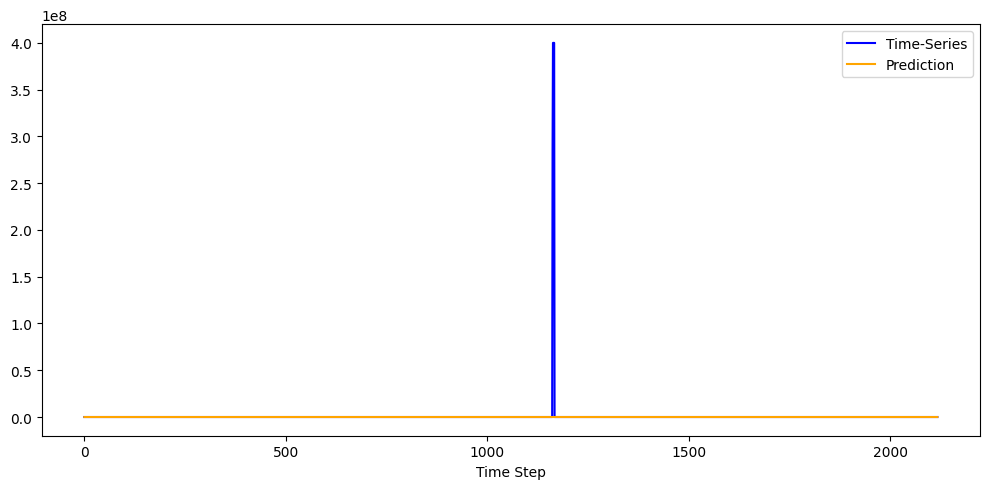

Channel T-8 Signal...
Epoch   5 | Train Loss: 0.482658 | Val Loss: 0.392018
Epoch  10 | Train Loss: 0.055085 | Val Loss: 0.020360
Epoch  15 | Train Loss: 0.050570 | Val Loss: 0.011096
Epoch  20 | Train Loss: 0.046875 | Val Loss: 0.007394
Epoch  25 | Train Loss: 0.043441 | Val Loss: 0.003506
Epoch  30 | Train Loss: 0.040226 | Val Loss: 0.000652
Epoch  35 | Train Loss: 0.039689 | Val Loss: 0.000378
Epoch  40 | Train Loss: 0.039878 | Val Loss: 0.000360
Epoch  45 | Train Loss: 0.039947 | Val Loss: 0.000291
Early stopping at epoch 47

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


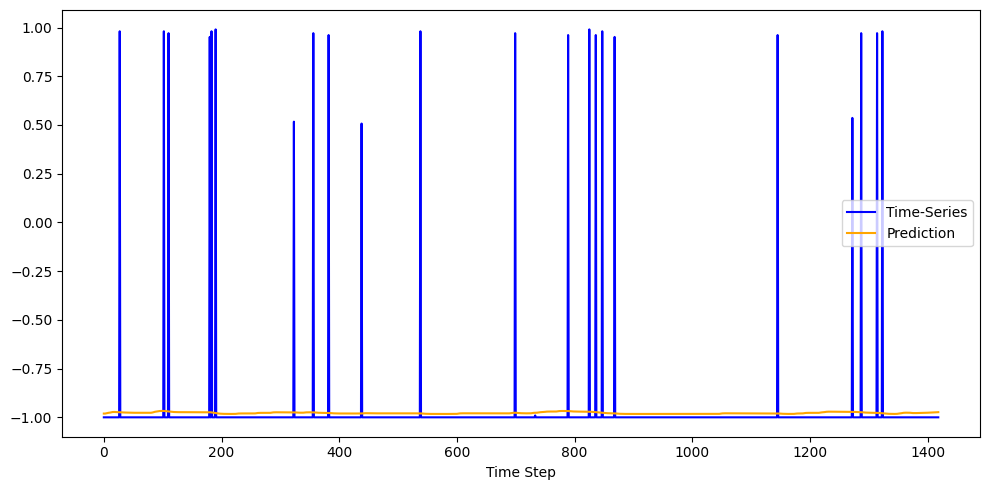

Channel T-9 Signal...
Epoch   5 | Train Loss: 0.039612 | Val Loss: 0.030662
Epoch  10 | Train Loss: 0.015789 | Val Loss: 0.009935
Epoch  15 | Train Loss: 0.015601 | Val Loss: 0.009728
Epoch  20 | Train Loss: 0.015341 | Val Loss: 0.009792
Epoch  25 | Train Loss: 0.015338 | Val Loss: 0.009612
Epoch  30 | Train Loss: 0.015659 | Val Loss: 0.009545
Epoch  35 | Train Loss: 0.015254 | Val Loss: 0.009519
Epoch  40 | Train Loss: 0.015272 | Val Loss: 0.009449
Early stopping at epoch 40

Metrics
-------
Precision = 0.0000
Recall = 0.0000
F1 = 0.0000


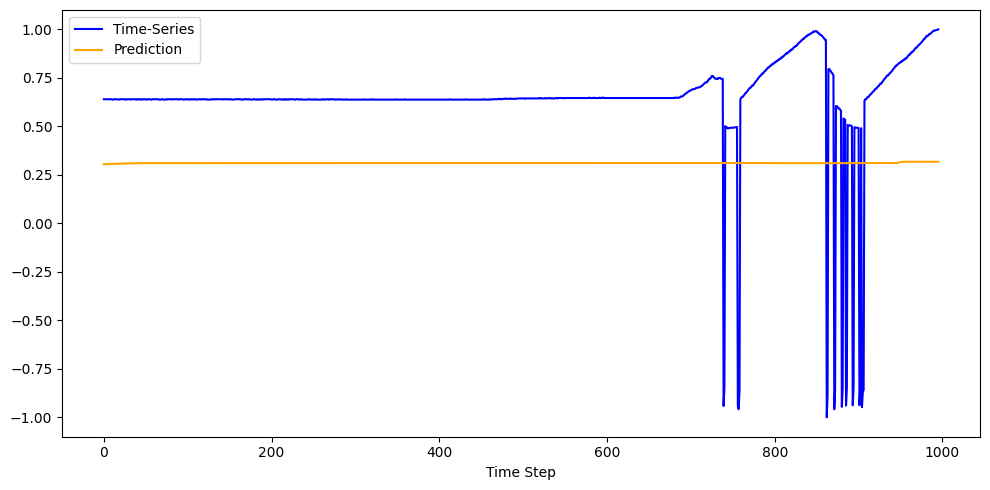

-----------
MSL Metrics
-----------
Precision: 0.274
Recall: 0.630
F1: 0.346



In [47]:
total_precision, total_recall, total_f1, total_evaluated = 0, 0, 0, 0

for msl_channel, X_train, X_test, y_test in zip(msl_channel_names, msl_train, msl_test, msl_test_y):
    # all data points are considered to be normal in the training tensor,
    # thus the labels consist of a tensor full of zeros
    y_train = torch.zeros(X_train.shape[0])

    print(f"Channel {msl_channel} Signal...")

    X_train = np.expand_dims(X_train[:, 0], axis=1)
    X_test = np.expand_dims(X_test[:, 0], axis=1)
    try:
        precision, recall, f1 = run_pipeline(
            X=X_train, 
            y=y_train, 
            X_test=X_test, 
            y_test=y_test,
            **MSL_HYPERPARAMS
        )
        total_precision += precision
        total_recall += recall
        total_f1 += f1
        total_evaluated += 1
    except:
        continue

total_precision /= total_evaluated
total_recall /= total_evaluated
total_f1 /= total_evaluated

print("-----------")
print("MSL Metrics")
print("-----------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

### **SMAP**

In [48]:
SMAP_HYPEPARAMS = NASA_HYPERPARAMS.copy()
SMAP_HYPEPARAMS["verbose"] = False

In [49]:
smap_split_url = f"{NASA_SPLIT_REPO}{NASA_SMAP_SPLIT}"
smap_split = pd.read_csv(smap_split_url)

# extract the file names corresponding to the SMAP dataset
smap_channels_names = list(smap_split["chan_id"].values)
# add the .npy file extensions to the SMAP file names
smap_file_names = [f"{smap_file_name}.npy" for smap_file_name in smap_channels_names]
# sort them alphabetically
smap_file_names.sort()

In [50]:
smap_train: list[np.ndarray] = []
smap_test: list[np.ndarray] = []
smap_test_y: list[list] = []

for smap_file_name in smap_file_names:
    # load both the train and test time series for the same channel, concatenate
    # the time series and add them to the MSL dataset
    smap_train_ts = np.load(os.path.join(nasa_train_path, smap_file_name))
    smap_test_ts = np.load(os.path.join(nasa_test_path, smap_file_name))

    # extract the anomaly labels for the test time-series
    # -4 is needed to get rid of the file extension from the name
    row = nasa_labels[nasa_labels["chan_id"] == smap_file_name[:-4]]
    smap_test_interval_str = row["anomaly_sequences"].iloc[0]
    smap_test_interval = ast.literal_eval(smap_test_interval_str)
    smap_test_labels = intervals_to_points(smap_test_interval, len(smap_test_ts))

    smap_train.append(smap_train_ts)
    smap_test.append(smap_test_ts)

    smap_test_y.append(smap_test_labels)

In [51]:
total_precision, total_recall, total_f1, total_evaluated = 0, 0, 0, 0

for smap_channel, X_train, X_test, y_test in zip(smap_channels_names, smap_train, smap_test, smap_test_y):
    # all data points are considered to be normal in the training tensor,
    # thus the labels consist of a tensor full of zeros
    y_train = torch.zeros(X_train.shape[0])
    
    print(f"Channel {smap_channel} Signal...")

    try:
        precision, recall, f1 = run_pipeline(
            X=X_train, 
            y=y_train, 
            X_test=X_test, 
            y_test=y_test,
            **SMAP_HYPEPARAMS
        )
        total_precision += precision
        total_recall += recall
        total_f1 += f1
        total_evaluated += 1
    except:
        continue

total_precision /= total_evaluated
total_recall /= total_evaluated
total_f1 /= total_evaluated

print("-----------")
print("SMAP Metrics")
print("-----------")
print(f"Precision: {total_precision:.3f}")
print(f"Recall: {total_recall:.3f}")
print(f"F1: {total_f1:.3f}")
print()

Channel A-1 Signal...
Channel A-2 Signal...
Channel A-3 Signal...
Channel A-4 Signal...
Channel A-5 Signal...
Channel A-6 Signal...
Channel A-7 Signal...
Channel A-8 Signal...
Channel A-9 Signal...
Channel B-1 Signal...
Channel D-1 Signal...
Channel D-11 Signal...
Channel D-12 Signal...
Channel D-13 Signal...
Channel D-2 Signal...
Channel D-3 Signal...
Channel D-4 Signal...
Channel D-5 Signal...
Channel D-6 Signal...
Channel D-7 Signal...
Channel D-8 Signal...
Channel D-9 Signal...
Channel E-1 Signal...
Channel E-10 Signal...
Channel E-11 Signal...
Channel E-12 Signal...
Channel E-13 Signal...
Channel E-2 Signal...
Channel E-3 Signal...
Channel E-4 Signal...
Channel E-5 Signal...
Channel E-6 Signal...
Channel E-7 Signal...
Channel E-8 Signal...
Channel E-9 Signal...
Channel F-1 Signal...
Channel F-2 Signal...
Channel F-3 Signal...
Channel G-1 Signal...
Channel G-2 Signal...
Channel G-3 Signal...
Channel G-4 Signal...
Channel G-6 Signal...
Channel G-7 Signal...
Channel P-1 Signal...
Cha